In [109]:
import calendar, glob, os

import pickle as pkl
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.colors as mcolors
import matplotlib.dates as mdates

from datetime import datetime

from skfda.exploratory.depth import ModifiedBandDepth, IntegratedDepth
from skfda import FDataGrid

from matplotlib import cm
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.transforms import ScaledTranslation
from matplotlib.ticker import FuncFormatter

from fdu import functional_dynamic_update
from utils import _get_hyper, _get_band_fraction, _KS, _bias_corrected_forecast
from fda import _fDepth, _fQuantile

plt.rcParams["legend.handlelength"] = 1
plt.rcParams["legend.handleheight"] = 1.125
plt.rcParams["font.family"] = "Avenir"

path_to_fDepth = "/Users/Guille/Desktop/dynamic_update/functional_forecast_dynamic_update/fDepth"
path_to_data = "/Users/Guille/Desktop/dynamic_update/data"
path_to_images = "/Users/Guille/Desktop/dynamic_update/images"
#path_to_params = "/Users/Guille/Desktop/dynamic_update/params"
path_to_validation = "/Users/Guille/Desktop/dynamic_update/validation"

# Loading color palette
palette_ = pd.read_csv(path_to_data + "/palette.csv")

# Loading Texas map
TX_ = gpd.read_file(path_to_data + "/maps/TX/State.shp")

# Historical random curves and day-ahead forecasts

In [110]:
## -------------------------- LOAD DATA ---------------------------------
resource = 'solar'
method = 'fusion'
type = 'asset'
unbiased = True
T = 288

# Load 2017 data as training set
with open(path_to_data + f"/preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
#print(F_tr_.shape, E_tr_.shape)

# Load 2018 data as testing set
with open(path_to_data + f"/preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
F_ts_ = _data["observations"]
E_ts_ = _data["forecasts"]
#print(assets_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
#print(F_ts_.shape, E_ts_.shape)

# Short testing set with training set order
order = {v: i for i, v in enumerate(assets_tr_)}
idx_ = np.argsort([order[x] for x in assets_ts_])
F_ts_ = F_ts_[:, :, idx_]
E_ts_ = E_ts_[:, :, idx_]
#print(F_ts_.shape, E_ts_.shape)

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
#print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))

# No possible capacity factor is larger than 1 or smaller than 0
F_tr_ = np.clip(F_tr_, 0., 1.)
F_ts_ = np.clip(F_ts_, 0., 1.)
E_tr_ = np.clip(E_tr_, 0., 1.)
E_ts_ = np.clip(E_ts_, 0., 1.)
F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()
print(F_tr_.min(), F_tr_.max(), E_tr_.min(), E_tr_.max())
print(F_ts_.min(), F_ts_.max(), E_ts_.min(), E_ts_.max())

# Format training set from day x interval x asset to [day * asset] x interval
E_ts_bias_ = E_ts_.copy()
E_tr_bias_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
#print(E_tr_bias_.shape, E_ts_bias_.shape)

## LOAD UNBIASED DATA WITH LINEAR INTERPOLATION
# Load 2017 data as training set
with open(path_to_data + f"/linear_preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
F_tr_ = _data["observations"]
E_tr_ = _data["forecasts"]
#print(assets_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
#print(F_tr_.shape, E_tr_.shape)

# Load 2018 data as testing set
with open(path_to_data + f"/linear_preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
F_ts_ = _data["observations"]
E_ts_ = _data["forecasts"]
#print(assets_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
#print(F_ts_.shape, E_ts_.shape)

# Short testing set with training set order
order = {v: i for i, v in enumerate(assets_tr_)}
idx_ = np.argsort([order[x] for x in assets_ts_])
F_ts_ = F_ts_[:, :, idx_]
E_ts_ = E_ts_[:, :, idx_]
#print(F_ts_.shape, E_ts_.shape)

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
#print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))

# Bias-correct the forecasts
if unbiased:
    E_tr_ = _bias_corrected_forecast(F_tr_, E_tr_)
    E_ts_ = _bias_corrected_forecast(F_ts_, E_ts_)
    print(E_tr_.shape, E_ts_.shape)

# No possible capacity factor is larger than 1 or smaller than 0
F_tr_ = np.clip(F_tr_, 0., 1.)
F_ts_ = np.clip(F_ts_, 0., 1.)
E_tr_ = np.clip(E_tr_, 0., 1.)
E_ts_ = np.clip(E_ts_, 0., 1.)
F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()
print(F_tr_.min(), F_tr_.max(), E_tr_.min(), E_tr_.max())
print(F_ts_.min(), F_ts_.max(), E_ts_.min(), E_ts_.max())

# Format training set from day x interval x asset to [day * asset] x interval
E_ts_lin_ = E_ts_.copy()
E_tr_lin_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
#print(E_ts_lin_.shape, E_tr_lin_.shape)

## LOAD UNBIASED DATA
# Load 2017 data as training set
with open(path_to_data + f"/preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
X_tr_ = _data["locations"]
dates_tr_ = _data["dates"]
F_tr_ = _data["observations"]
E_tr_ = _data["forecasts"]
#print(assets_tr_.shape, X_tr_.shape, dates_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
T_tr_ = dates_tr_.reshape(int(dates_tr_.shape[0]/T), T)
#print(F_tr_.shape, E_tr_.shape, T_tr_.shape)

# Load 2018 data as testing set
with open(path_to_data + f"/preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
X_ts_ = _data["locations"]
dates_ts_ = _data["dates"]
F_ts_ = _data["observations"]
E_ts_ = _data["forecasts"]
#print(assets_ts_.shape, X_ts_.shape, dates_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
T_ts_ = dates_ts_.reshape(int(dates_ts_.shape[0]/T), T)
#print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

dt_ = np.array([t * 5 for t in range(T)])
dx_ = pd.to_datetime(pd.DataFrame({"time": dt_}).time, unit = "m").dt.strftime("%H:%M").to_numpy()
#print(dt_.shape, dx_.shape)

# Short testing set with training set order
order = {v: i for i, v in enumerate(assets_tr_)}
idx_ = np.argsort([order[x] for x in assets_ts_])
assets_ts_ = assets_ts_[idx_]
X_ts_ = X_ts_[idx_]
F_ts_ = F_ts_[:, :, idx_]
E_ts_ = E_ts_[:, :, idx_]
#print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
#print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))
# print(F_tr_.min(), F_tr_.max())
# print(E_tr_.min(), E_tr_.max())
# print(F_ts_.min(), F_ts_.max())
# print(E_ts_.min(), E_ts_.max())

# Unbias the forecasts
if unbiased:
    E_tr_ = _bias_corrected_forecast(F_tr_, E_tr_)
    E_ts_ = _bias_corrected_forecast(F_ts_, E_ts_)
    print(E_tr_.shape, E_ts_.shape)

# No possible capacity factor is larger than 1 or smaller than 0
F_tr_ = np.clip(F_tr_, 0., 1.)
F_ts_ = np.clip(F_ts_, 0., 1.)
E_tr_ = np.clip(E_tr_, 0., 1.)
E_ts_ = np.clip(E_ts_, 0., 1.)
F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()
print(F_tr_.min(), F_tr_.max(), E_tr_.min(), E_tr_.max())
print(F_ts_.min(), F_ts_.max(), E_ts_.min(), E_ts_.max())

# Format training set from day x interval x asset to [day * asset] x interval
T_tr_ = np.concatenate([T_tr_ for k in range(assets_tr_.shape[0])], axis = 0)
assets_tr_ = np.concatenate([np.tile(assets_tr_[k], (F_tr_.shape[0], 1)) for k in range(assets_tr_.shape[0])], axis = 0)
X_tr_ = np.concatenate([np.tile(X_tr_[k, :], (F_tr_.shape[0], 1)) for k in range(X_tr_.shape[0])], axis = 0)
F_tr_ = np.concatenate([F_tr_[..., k] for k in range(F_tr_.shape[2])], axis = 0)
E_tr_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
#print(X_tr_.shape, assets_tr_.shape, F_tr_.shape, E_tr_.shape, T_tr_.shape)
#print(X_ts_.shape, assets_ts_.shape, F_ts_.shape, E_ts_.shape, T_ts_.shape)

t_tr_ = np.array([datetime.strptime(t_tr, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday for t_tr in T_tr_[:, 0]]) - 1
t_ts_ = np.array([datetime.strptime(t_ts, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday for t_ts in T_ts_[:, 0]]) - 1
#print(t_tr_.shape, t_ts_.shape)

dt_ = np.array([t * 5 for t in range(T)])
dt_p_ = dt_ + 5
dx_ = pd.to_datetime(pd.DataFrame({"time": dt_p_}).time, unit = "m").dt.strftime("%H:%M").to_numpy()
#print(dt_.shape, dx_.shape)

0.0 1.0 0.0 1.0
0.0 1.0 0.0 1.0
(363, 288, 211) (364, 288, 211)
0.0 1.0 0.0 1.0
0.0 1.0 0.0 1.0
(363, 288, 211) (364, 288, 211)
0.0 1.0 0.0 1.0
0.0 1.0 0.0 1.0


In [111]:
def _update_hyper_base(df1, df2, inits = {72: 1, 144: 1, 216: 1}):
    df = df1.copy()
    for interval in inits:
        for parameter in list(df2.columns[-5:]):
            idx_ = (df2['time'] == interval) & (df2['initialization'] == inits[interval])
            df.loc[parameter, interval] = np.around(df2.loc[idx_, parameter].values[0], 3)
    return df

# wind biased_sel {72: 3, 144: 1, 216: 1}
# wind unbiased_sel {72: 2, 144: 4, 216: 2}
# solar biased_sel {120: 2, 144: 4, 168: 2}
# solar unbiased_sel {120: 2, 144: 4, 168: 2}

file_name = f'{resource}_{method}_{type}-hyper-base.csv'
hyper_base = pd.read_csv(path_to_validation + f"/{file_name}")
hyper_base = hyper_base.set_index("parameter")
hyper_base.columns = hyper_base.columns.astype(int)
print(hyper_base)

file_name = f'{resource}_{method}_{type}-hyper-biased_sel.csv'
hyper_val = pd.read_csv(path_to_validation + f"/{resource}/{file_name}")

hyper_ = _update_hyper_base(hyper_base, hyper_val, 
                            inits = {72: 1, 144: 5, 216: 1})
print(hyper_)

file_name = f'{resource}_{method}_{type}-envelope-biased_sel.csv'
envelope_ = pd.read_csv(path_to_validation + f"/{resource}/{file_name}")
envelope_ = envelope_.set_index("time")
print(envelope_)

                       120         144         168
parameter                                         
forget_rate_f     2.000000    0.230896    2.000000
forget_rate_e    16.000000   16.000000   16.000000
lookup_rate      10.000000   10.000000   10.000000
length_scale_f    0.121431    0.088152    0.201965
length_scale_e    1.460833    1.185769    5.000000
trust_rate        0.250000    0.250000    0.250000
nu                6.000000    6.000000    6.000000
xi                0.650000    0.650000    0.650000
gamma            45.000000   45.000000   45.000000
kappa           175.000000  175.000000  175.000000
p_fusion          0.750000    0.750000    0.750000


FileNotFoundError: [Errno 2] No such file or directory: '/Users/Guille/Desktop/dynamic_update/validation/solar/solar_fusion_asset-hyper-biased_sel.csv'

# Functional kNNs dynamic update

In [130]:
# def _get_hyper(hyper_, param, time):
#     x_ = hyper_.loc[param].to_numpy()
#     time_ = hyper_.loc[param].index.to_numpy()
#     return np.interp(time, time_, x_)
    
# 21-289
# solar-21-120-132
# 21-122-132
# solar-21-130-132
# solar-22-120-132
# solar-22-116-132
asset = 15                                                                                                                                                                                                                                                                 
day = 95
interval = 168

_distances = {'temporal': 'seasonal_equinox', 'spatial': 'haversine'}

_fdu = functional_dynamic_update(_distances, assets_ts_[asset], T_ts_[day, interval])
print(_fdu.name, _fdu.date)

# x_ts = x_ts_[asset, :]
# t_ts = t_ts_[day]

# Filter solar hours with loading solar set
idx_days_ = np.absolute(t_tr_ - day) < 7
idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) + np.sum(E_tr_bias_[idx_days_, :], axis = 0)) > 1.

_fdu.fit(F_tr_, E_tr_lin_, dt_, 
         X_ = X_tr_, 
         t_ = t_tr_, 
         interval_mask = idx_hours_,
         n_samples_per_hour = 12)

# M_ = _fdu.predict(F_ts_[day, :interval, asset], E_ts_lin_[day, :, asset], x_ts_[asset, :], t_ts_[day],
#                   forget_rate_f = _get_hyper(hyper_, 'forget_rate_f', interval),
#                   forget_rate_e = _get_hyper(hyper_, 'forget_rate_e', interval),
#                   length_scale_f = _get_hyper(hyper_, 'length_scale_f', interval),
#                   length_scale_e = _get_hyper(hyper_, 'length_scale_e', interval),
#                   lookup_rate = _get_hyper(hyper_, 'lookup_rate', interval),
#                   trust_rate = _get_hyper(hyper_, 'trust_rate', interval),
#                   nu = _get_hyper(hyper_, 'nu', interval),
#                   gamma = _get_hyper(hyper_, 'gamma', interval),
#                   xi = _get_hyper(hyper_, 'xi', interval),
#                   kappa = _get_hyper(hyper_, 'kappa', interval),
#                   p_fusion = _get_hyper(hyper_, 'p_fusion', interval))

# 0.0625	0.086033853	1	8.164675269	0.05	0.05	37	75
# 0.0625	3.247504994	1	6.540719254	0.213417129	0.05	37	75
M_ = _fdu.predict(F_ts_[day, :interval, asset], E_ts_lin_[day, :, asset], X_ts_[asset, :], t_ts_[day],
                  forget_rate_f = 0.0625,
                  forget_rate_e = 3.,
                  length_scale_f = 0.0025,
                  length_scale_e = 1.,
                  lookup_rate = 1,
                  nu = 6,
                  trust_rate = .21,
                  xi = 0.05,
                  gamma = 37,
                  kappa = 75,
                  p_fusion = 0.75)

f_ = F_ts_[day, :interval, asset]
f_hat_ = F_ts_[day, interval:, asset]
e_ = E_ts_[day, :, asset]
e_lin_ = E_ts_lin_[day, :, asset]
e_bias_ = E_ts_bias_[day, :, asset]

file_name = f"{resource}-{asset}-{day}-{interval}-asset"
print(file_name)

print(_fdu.idx_neighbors_.shape, _fdu.idx_temporal_.shape, _fdu.idx_spatial_.shape)

Blackwater Draw Solar 2018-04-06 14:00:00
solar-15-95-168-asset
(3869,) (1032,) (75,)


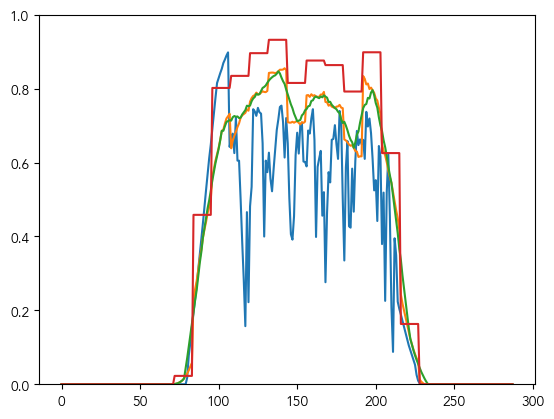

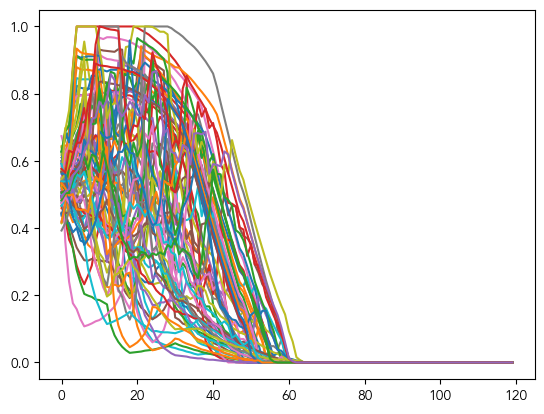

In [131]:
plt.figure()
plt.plot(F_ts_[day, :, asset])
plt.plot(e_)
plt.plot(e_lin_)
plt.plot(e_bias_)
plt.ylim(0, 1)
plt.show()

plt.figure()
plt.plot(M_.T)
plt.show()

# Visualization Utils

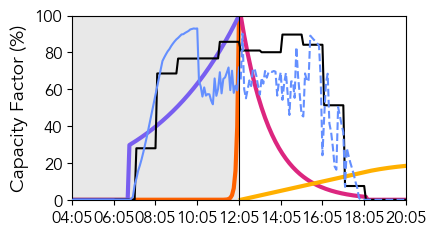

In [114]:
def _plot_forecast_parameters(_ax, phi_, psi_, eta_, f_, f_hat_, e_, dx_, dt_, interval,
                              range_ = [48, 240],
                              labels_1 = False,
                              labels_2 = False):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]
    dt   = dt_[1] - dt_[0]

    _ax.plot(tau_ + dt, 100. * f_, 
             c=palette_.loc[0, "ibm"], 
             label="CF (actual)" if labels_1 else None, 
             lw=1.5, 
             zorder=5)

    _ax.plot(s_ + dt, 100. * f_hat_, 
             c=palette_.loc[0, "ibm"], 
             lw=1.5, 
             ls="--", 
             zorder=5)

    _ax.plot(dt_ + dt, 100. * e_, 
             lw=1.5, 
             label="CF (forecast)" if labels_1 else None, 
             c="k", 
             zorder=4)

    _ax.axvline(dt_[interval - 1] + dt, 
                color="k", 
                lw=0.75, 
                label="Event (update)" if labels_1 else None, 
                zorder=6)

    _ax.plot(tau_ + dt, 100. * phi_,
             c=palette_.loc[3, "ibm"],
             lw=3,
             label=r"$\phi_{\varepsilon_f} (\tau)$" if labels_2 else None,
             zorder=2)
    
    _ax.plot(tau_ + dt, 100. * psi_[:interval],
             c=palette_.loc[1, "ibm"],
             lw=3,
             label=r"$\phi_{\varepsilon_e} (\tau)$" if labels_2 else None,
             zorder=2)

    _ax.plot(s_ + dt, 100. * psi_[interval:],
             c=palette_.loc[2, "ibm"],
             lw=3,
             label=r"$\psi_{\eta} (s)$" if labels_2 else None,
             zorder=2)

    _ax.plot(s_ + dt, 100. * eta_,
             c=palette_.loc[4, "ibm"],
             lw=3,
             label=r"$\sigma_{\alpha} (s)$" if labels_2 else None,
             zorder=2)

    _ax.fill_between(tau_ + dt, 100. * np.ones(tau_.shape), 100. * np.zeros(tau_.shape),
                     color="lightgray",
                     alpha=0.5,
                     zorder=1)

    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation=0)
    _ax.set_ylabel("Capacity Factor (%)", size=14)
    _ax.tick_params(axis="both", labelsize=12)
    _ax.set_ylim(0, 100)
    _ax.set_xlim(dt_[range_[0]], dt_[range_[1]])

fig, _ax = plt.subplots(figsize = (4.25, 2.25), 
                        constrained_layout = True)

_plot_forecast_parameters(_ax, _fdu.phi_, _fdu.psi_, _fdu.eta_, f_, f_hat_, e_bias_, dx_, dt_p_, interval,
                          labels_1 = True,
                          labels_2 = False)

# _ax.legend(frameon=False, 
#            ncol=2, 
#            loc=(0.0125,0.7), 
#            #loc=(0.362,0.625), 
#            fontsize=12)
        
plt.savefig(path_to_images + f"/hyper-{file_name}.pdf", 
            bbox_inches = "tight")

plt.show()

In [115]:
def _plot_envelop(_ax, _U, _L, f_, f_hat_, e_, m_, dt_, dx_, t, 
                  range_ = [60, 240],
                  color = palette_.loc[4, "ibm"],
                  label = r"$\bar{\mu} (s)$",
                  CR = 'CR',
                  legend_1 = True, 
                  legend_2 = True):

    tau_ = dt_[:t]
    s_   = dt_[t:]
    dt   = dt_[1] - dt_[0]

    _ax.plot(dt_ + dt, 100 * e_, 
             c = "k", 
             lw = 2, 
             clip_on = True,
             label = "CF (forecast)" if legend_1 else None, 
             zorder = 8)

    _ax.plot(tau_ + dt, 100 * f_, 
             c = palette_.loc[0, "ibm"], 
             clip_on = True,
             label = "CF (actual)" if legend_1 else None, 
             lw = 2, 
             zorder = 9)
    
    _ax.plot(s_ + dt, 100 * f_hat_, 
             clip_on = True,
             c = palette_.loc[0, "ibm"], 
             ls = "--", 
             lw = 2, 
             zorder = 9)

    _ax.plot(s_ + dt, 100 * m_, 
             c = color, 
             label = label if legend_2 else None,
             lw = 2, 
             zorder = 10)
    
    # _ax.plot(s_ + dt, 100 * m_, 
    #          c = 'k', 
    #          lw = .25, 
    #          zorder = 11)
    
    colors_ = ["lightgray", "darkgray", "gray", "dimgray"]
    for color, key, i in zip(colors_, _U.keys(), range(len(_U.keys()))):
        u_ = _U[key]
        l_ = _L[key]
    
        # _ax.plot(dt_[-u_.shape[0]:] + dt, 100 * u_, 
        #          lw = 0.125, 
        #          zorder = i + 10,
        #          c = "k")
        
        # _ax.plot(dt_[-l_.shape[0]:] + dt, 100 * l_, 
        #          lw = 0.125, 
        #          zorder = i + 10,
        #          c = "k")

        cr = int((1. - float(key))*100)
        
        _ax.fill_between(dt_[-u_.shape[0]:] + dt, 100*u_, 100*l_,
                        color  = color,
                        label  = f"{cr}% {CR}" if legend_2 else None,
                        zorder = i + 1)

    _ax.fill_between(tau_ + dt, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color = "lightgray",
                     alpha = 0.5)

    _ax.axvline(dt_[t - 1] + dt, 
                color = "k", 
                linewidth = 0.75, 
                #label = "Event (update)",
                zorder = 11)
    
    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation=0)
        
    _ax.tick_params(axis = "both", 
                    labelsize = 12)
    
    _ax.set_ylim(0, 101)
    _ax.set_xlim(dt_[range_[0]], dt_[range_[-1]])
    _ax.set_ylabel("Capacity Factor (%)", size = 14)

def _focal_curve_envelope(_depth, Y_, dt_, dist_, 
                          max_iter = 100,
                          idx_focal = 0):
    """
    Envelope algorithm to obtain functional neighbourhoods.

    Parameters
    ----------
    data : dict
        Dictionary with keys:
            - "x": np.ndarray of grid points (n_points,)
            - "y": np.ndarray of function values (n_points, n_curves)
    focal : int or str
        Index (or column name) of the focal curve to envelope.
    plot : bool, optional
        Whether to plot the selected curves in each iteration.
    max_iter : int, optional
        Maximum number of iterations before stopping.

    Returns
    -------
    dict
        Dictionary with key 'Jordered' containing the ordered list
        of selected curve indices.
    """
    Y_ = Y_.T
    # Compute depth to find the focal curve
    _fd_filtered = FDataGrid(data_matrix = Y_.T,
                             grid_points = dt_)
    
    #filtered_depth_ = _depth(_fd_filtered)
    # idx_focal       = np.argsort(-filtered_depth_)[0]
    f_ = Y_[:, idx_focal]

    if isinstance(dist_, str):
        # Distances from curves to the focal curve
        if dist_ == 'sup':
            dist_ = np.max(np.abs(Y_.T - f_), axis = 1)
        elif dist_ == 'l2':
            dist_ = np.sum((Y_.T - f_)**2, axis = 1)
            
    # Initialize
    idx_subsample = []
    idx_          = [i for i in range(Y_.shape[1]) if i != idx_focal]
    iter_depth    = [0]
    iteration     = 0

    while len(idx_) > 1:
        
        # New iteration
        iteration += 1
        
        # Sort curves by distance
        idx_sorted_dist_   = [idx_[i] for i in np.argsort(dist_[idx_])]
        idx_iter_subsample = [idx_sorted_dist_[0]]
        idx_candidates     = idx_sorted_dist_[1:]
        # Iterative envelope selection
        remaining_points = set(dt_)
        while remaining_points and idx_candidates:
            idx_next = idx_candidates[0]
            combined = idx_iter_subsample + [idx_next]
            
            # Check if envelopes
            sign_ = np.sign(Y_[:, combined].T - f_)
            Ji_   = np.where(np.abs(np.sum(sign_, axis = 0)) < len(combined))[0]
            
            if len(remaining_points - set(dt_[Ji_]) ) == len(remaining_points):
                # Does not envelope
                idx_candidates.pop(0)
            else:
                remaining_points -= set(dt_[Ji_])
                
                idx_iter_subsample.append(idx_next)
                
                idx_candidates = [c for c in idx_candidates if c not in idx_iter_subsample]
                idx_           = [c for c in idx_ if c not in idx_iter_subsample]

        # Compute functional depth 
        _fd_subset = FDataGrid(data_matrix = (Y_[:, [idx_focal] 
                                                 + idx_subsample 
                                                 + idx_iter_subsample]).T,
                               grid_points = dt_)
    
        depth_             = _depth(_fd_subset)
        idx_depth_         = np.argsort(-depth_)
        idx_ordered_depth_ = np.array([idx_focal] + idx_subsample + idx_iter_subsample)[idx_depth_]

        # How deep the new set of curves is?
        depth_percentile = 1 - np.where(idx_ordered_depth_ == idx_focal)[0][0]/(len(idx_ordered_depth_) - 1)
        
        iter_depth.append(depth_percentile)

        # Accept subsample if depth improves
        if max(iter_depth[:-1]) <= iter_depth[-1]:
            idx_subsample.extend(idx_iter_subsample)
            
        # Stop if there is not more candidate curves
        if not idx_candidates:
            break
            
        # Stop if max_iter is reached
        if iteration >= max_iter:
            break

    # Selected curves
    idx_sel_ = [idx_focal] + idx_subsample
    
    # Final selected curves ordered by depth
    _fd_filtered = FDataGrid(data_matrix = Y_[:, idx_sel_].T,
                             grid_points = dt_)
        
    filtered_depth_             = _depth(_fd_filtered)
    idx_filtered_depth_         = np.argsort(-filtered_depth_)
    idx_ordered_filtered_depth_ = np.array(idx_sel_)[idx_filtered_depth_]

    return Y_[:, idx_ordered_filtered_depth_].T

# Confidence bands from focal-curve envelop
def _confidence_bands_from_focal_envelop(J_, alpha_, k_, f_0):    

    _U = {}
    _L = {}
    for i in range(len(alpha_)):
        N = int(k_[i]*J_.shape[1])
        _U[f'{alpha_[i]}'] = np.insert(np.max(J_[:N, :], axis = 0), 0, f_0)
        _L[f'{alpha_[i]}'] = np.insert(np.min(J_[:N, :], axis = 0), 0, f_0)
        
    # Focal-curve
    m_ = np.insert(J_[:, 0], 0, f_0)
    
    return m_, _L, _U

def _get_envelop_franction(envelop_, alpha_, dist, time):
    k_ = []
    for alpha in alpha_:
        idx_ = (envelop_['alpha'] == alpha) & (envelop_['distance'] == dist)
        x_ = envelop_.loc[idx_, 'fraction'].to_numpy()
        time_ = envelop_.loc[idx_].index.to_numpy()
        k_.append(np.interp(time, time_, x_))
    return np.array(k_)
    
# Downsample collection of curves
def _functional_downsampling(X_, dt_, x_, subsample, n_basis = 20):

    n_samples, n_points = X_.shape

    X_ = np.concatenate([x_, X_], axis = 1)
    # Ensure the length is divisible by subsample
    dt    = dt_[1] - dt_[0]
    t_    = dt_[-n_points-1:]
    t_ds_ = np.linspace(t_[1], t_[-1], int(n_points/subsample))

    # Create an FDataGrid object
    data_ = [X_[i, :] for i in range(n_samples)]
    _fd   = FDataGrid(data_matrix = data_, 
                      grid_points = t_)

    # Interpolate first (useful if data are unevenly spaced or need smoothing)
    _fd_interp = _fd.to_basis(BSpline(n_basis = n_basis))
    M_interp_  = _fd_interp.to_grid(t_)
    M_interp_  = np.stack([M_interp_.data_matrix[i] 
                           for i in range(n_samples)])[..., 0]
    
    # Re-evaluate existing data
    M_interp_ds_ = _fd_interp.to_grid(t_ds_)
    M_interp_ds_ = np.stack([M_interp_ds_.data_matrix[i] 
                             for i in range(n_samples)])[..., 0]

    return M_interp_, M_interp_ds_, t_ds_
    
# Samples in each confidence band
dist = 'fknn'
alpha_ = [0.1, 0.2, 0.3, 0.4]

f_0 = f_[-1]
f_0_ = np.ones(_meta['m_0'].shape)*f_0
focal_curve_p_ = np.concatenate([_meta['m_0'][0], _meta['focal_curve']], axis = 0)

M_interp_, M_interp_ds_, dt_p_ = _functional_downsampling(M_, dt_,
                                                          x_ = f_0_,
                                                          subsample = 12,
                                                          n_basis = int(M_.shape[1]/5)) 

if dist == 'fknn':
    dist_ = np.insert(_meta['w_p'], 0, 0)
else:
    dist_ = dist

M_interp_ = np.concatenate([focal_curve_p_[np.newaxis], M_interp_], axis = 0)[:, 1:]
J_ = _focal_curve_envelope(ModifiedBandDepth(), 
                           Y_ = M_interp_, 
                           dt_ = dt_[-M_interp_.shape[1]:], 
                           dist_ = dist_,
                           max_iter = 100)

k_ = _get_envelop_franction(envelop_, alpha_, dist, time)

m_, _U, _L = _confidence_bands_from_focal_envelop(J_, alpha_, k_, f_0)

_fig, _ax = plt.subplots(figsize = (4.75, 2.25), constrained_layout = True)

_plot_envelop(_ax, _U, _L, f_, f_hat_, e_bias_, _meta['focal_curve'], dt_, dx_, time, 
              color = palette_.loc[4, "ibm"],
              #label = r"$\bar{f} (s)$",
              label = r"",
              CR = 'CR',
              legend_1 = False, 
              legend_2 = True)

_ax.legend(frameon = False, 
           loc = (0.4, .0),
           fontsize = 12,
           columnspacing=0.5,
           handletextpad=0.25,
           ncol = 1)

plt.savefig(path_to_images + f"/focal_curve_envelop-{file_name}.pdf", 
            bbox_inches = "tight")

plt.show()

NameError: name '_meta' is not defined

In [32]:
def _plot_depth(_fig, _ax, palette_, M_, f_, f_hat_, e_, w_, dx_, dt_, 
                range_ = [60, 240],
                colorbar = True):

    t    = dt_.shape[0] - M_.shape[1]
    tau_ = dt_[:t]
    s_   = dt_[t:]
    dt   = dt_[1] - dt_[0]

    idx_  = np.argsort(w_)
    _cmap = sns.color_palette("rocket", as_cmap=True)
    _norm = plt.Normalize(0., 1)

    _ax.plot([], [], 
             lw = 0.75,
             label = r"$\hat{\mu}_i(s)$", 
             c = "k")

    for i in range(idx_.shape[0]):
        _ax.plot(s_ + dt, 100. * M_[idx_[i], :],
                 c = _cmap(_norm(i/idx_.shape[0])), 
                 lw = 0.75, 
                 zorder = 0, 
                 clip_on = True)

    _ax.plot(dt_[:f_.shape[0]] + dt, 100. * f_,
             c = palette_.loc[0, "ibm"],
             #label = "CF (ac)",
             zorder = 9,
             lw = 2, 
             clip_on = True)

    _ax.plot(dt_[-f_hat_.shape[0]:] + dt, 100. * f_hat_,
             c = palette_.loc[0, "ibm"],
             zorder = 9,
             lw = 2,
             ls = "--", 
             clip_on = True)

    _ax.plot(dt_ + dt, 100. * e_, 
             lw = 2, 
             #label = "CF (fc)", 
             zorder = 8,
             c = "k", 
             clip_on = True)

    _ax.axvline(dt_[f_.shape[0] - 1] + dt, 
                color = "k", 
                lw = 1, 
                #label  = "Event (update)", 
                zorder = 10)
        
    _ax.fill_between(tau_ + dt, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color = "lightgray",
                     alpha = 0.5,
                     zorder = 1)
    
    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation=0)
    # ax_[2].set_yticks(size = 12)
    _ax.set_ylim(0, 101)
    _ax.set_xlim(dt_[range_[0]], dt_[range_[-1]])
    _ax.set_ylabel("Capacity Factor (%)", size=14)
    
    _ax.tick_params(axis = "both", 
                    labelsize = 12)
    
    if colorbar:
        cbar = _fig.colorbar(cm.ScalarMappable(_norm, sns.color_palette("rocket_r", as_cmap = True)),
                             cax = _ax.inset_axes([465, 15, 150, 5], transform = _ax.transData),
                             orientation = "horizontal")
    
        cbar.set_ticks([0, 1], 
                       labels = [1, M_.shape[0]], 
                       size = 12)
            
        cbar.ax.set_title("Depth Rank", 
                          rotation = 0, 
                          size = 12)
    
M_interp_, M_interp_ds_, dt_p_ = _functional_downsampling(M_, dt_,
                                                          x_ = f_0_,
                                                          subsample = 12,
                                                          n_basis = int(M_.shape[1]/5))                                                  

_fig, _ax = plt.subplots(figsize = (4.75, 2.25), constrained_layout = True)

depth = 'MBD'
depth_rank_ = _fDepth(M_interp_ds_, depth, path_to_fDepth).to_numpy()[:, 0]

_plot_depth(_fig, _ax, palette_, M_, f_, f_hat_, e_bias_, depth_rank_, dx_, dt_, 
            colorbar = True)

# _ax.legend(frameon = False, 
#            loc = (0.4, .825),
#            fontsize = 12,
#            columnspacing=0.5,
#            handletextpad=0.2,
#            ncol = 5)

plt.savefig(path_to_images + f"/ranking-{depth}_{file_name}.pdf", 
            bbox_inches = "tight")

plt.show()

NameError: name 'f_0_' is not defined

In [33]:
def _plot_enhanced_functional_boxplot(_ax, _upper, _lower, f_, f_hat_, e_, m_, dt_, dx_, t,
                                      range_ = [60, 240],
                                      legend_1 = True, 
                                      legend_2 = True):

    #t    = dt_.shape[0] - m_.shape[0]
    tau_ = dt_[:t]
    s_   = dt_[t:]
    dt   = dt_[1] - dt_[0]

    _ax.plot(dt_ + dt, 100 * e_, 
             c = "k", 
             lw = 2, 
             zorder = 8,
             #label = "CF (forecast)" if legend_1 else None
             clip_on = True)

    _ax.plot(tau_ + dt, 100 * f_, 
             c = palette_.loc[0, "ibm"], 
             #label = "CF (actual)" if legend_1 else None, 
             zorder = 9,
             lw = 2, 
             clip_on = True)

    _ax.plot(s_ + dt, 100 * f_hat_, 
             c  = palette_.loc[0, "ibm"], 
             lw = 2, 
             ls = "--", 
             zorder = 9,
             clip_on = True)
    #m_p_ = np.concatenate([f_[-1] * np.ones((1,)), m_], axis=0)

    _ax.plot(dt_[-m_.shape[0]:] + dt, 100 * m_, 
             c = palette_.loc[2, "ibm"], 
             ls = '-',
             zorder = 4,
             label = r"$\bar{\mu} (s)$" if legend_1 else None,
             lw = 2)
    
    u_ = _upper['max']
    l_ = _lower['min']

    _ax.plot(dt_[-u_.shape[0]:] + dt, 100 * u_, 
             c = 'k', 
             lw = .75, 
             zorder = 7)
    
    _ax.plot(dt_[-l_.shape[0]:] + dt, 100 * l_, 
             c = 'k', 
             lw = .75, 
             zorder = 7, 
             label = "min-max" if legend_2 else None)

    _upper.pop('max')
    _lower.pop('min')

    colors_ = ["lightgray", "darkgray", "gray"]

    for color, key, i in zip(colors_, _upper.keys(), range(len(_upper.keys()))):
        u_ = _upper[key]
        l_ = _lower[key]
        
        # _ax.plot(dt_[-u_.shape[0]:] + dt, 100*u_, 
        #          lw = 0.125, 
        #          zorder = i + 2,
        #          c = "k", clip_on = True)
        
        # _ax.plot(dt_[-l_.shape[0]:] + dt, 100*l_, 
        #          lw = 0.125, 
        #          zorder = i + 2,
        #          c = "k", clip_on = True)

        cr = int((1. - float(key)) * 100)
        
        _ax.fill_between(dt_[-u_.shape[0]:] + dt, 100*u_, 100*l_,
                         color = color,
                         label = f"{cr}% CR" if legend_2 else None,
                         zorder = i + 1)

    _ax.axvline(dt_[t - 1] + dt, 
                color = "k", 
                linewidth = 0.75, 
                #label = "Event (update)",
                zorder = 10)

    _ax.fill_between(tau_ + dt, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color = "lightgray",
                     alpha = 0.5)
    
    _ax.tick_params(axis = "both", 
                    labelsize = 12)
    
    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation=0)
    # ax_[2].set_yticks(size = 12)
    _ax.set_ylim(0, 101)
    _ax.set_xlim(dt_[range_[0]], dt_[range_[-1]])
    _ax.set_ylabel("Capacity Factor (%)", size=14)

# Functional boxplot from a smooth functional depth metric
def _functional_boxplot(M_downsampled_, 
                        M_upsampled_,
                        alpha_, 
                        depth, 
                        path):

    # Calculate functional depth ranking
    D_ = _fDepth(M_downsampled_, depth, path).to_numpy()[:, 0]

    I_ = np.argsort(D_)[::-1]

    _U = {}
    _L = {}
    for i in range(len(alpha_)):
        scenarios_         = M_upsampled_[I_[:-int(M_upsampled_.shape[0] * alpha_[i])],]
        _U[f'{alpha_[i]}'] = np.max(scenarios_, axis = 0)
        _L[f'{alpha_[i]}'] = np.min(scenarios_, axis = 0)

        _U[f'{alpha_[i]}'][_L[f'{alpha_[i]}'] > 1] = 1
        _L[f'{alpha_[i]}'][_L[f'{alpha_[i]}'] < 0] = 0

    m_        = M_upsampled_[I_[0],]
    _U['max'] = np.max(M_upsampled_, axis = 0)
    _L['min'] = np.min(M_upsampled_, axis = 0)

    return m_, _U, _L

depth  = 'MBD'
alpha_ = [0.25, 0.5, 0.75]

M_interp_, M_interp_ds_, dt_p_ = _functional_downsampling(M_, dt_,
                                                          x_ = f_0_,
                                                          subsample = 12,
                                                          n_basis = int(M_.shape[1]/5)) 

# Calculate confidence intervals from Directional Quantiles
m_, _upper, _lower = _functional_boxplot(M_interp_ds_, 
                                         M_interp_,
                                         alpha_, 
                                         depth, 
                                         path_to_fDepth)

_fig, _ax = plt.subplots(figsize = (4.25, 2.25), constrained_layout = True)

_plot_enhanced_functional_boxplot(_ax, _upper, _lower, f_, f_hat_, e_bias_, m_, dt_, dx_, time,
                                  legend_1 = False, 
                                  legend_2 = False)
    
_ax.legend(frameon = False, 
           loc = (0.1875, .825),
           fontsize = 12,
           columnspacing=0.5,
           handletextpad=0.2,
           ncol = 6)

plt.savefig(path_to_images + f"/fboxplot-{depth}_{file_name}.pdf", 
            bbox_inches = "tight")

plt.show()

NameError: name 'f_0_' is not defined

In [34]:
M_interp_, M_interp_ds_, dt_p_ = _functional_downsampling(M_, dt_,
                                                          x_ = f_0_,
                                                          subsample = 12,
                                                          n_basis = int(M_.shape[1]/5)) 

# Calculate confidence intervals from Directional Quantiles
med_, _U, _L = _confidence_bands_from_eCDF(M_interp_, alpha_)

_fig, _ax = plt.subplots(figsize = (4.25, 2.25), constrained_layout = True)

_plot_envelop(_ax, _U, _L, f_, f_hat_, e_bias_, med_[1:], dt_, dx_, time, 
              color = palette_.loc[3, "ibm"],
              CR = 'CI',
              label = r"$\bar{\mu} (s)$",
              legend_1 = False, 
              legend_2 = False)

_ax.legend(frameon = False, 
           loc = (0.1875, .825),
           fontsize = 12,
           columnspacing=0.5,
           handletextpad=0.25,
           ncol = 5)

plt.savefig(path_to_images + f"/EDF-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

NameError: name 'f_0_' is not defined

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(175, 157) (175, 156)


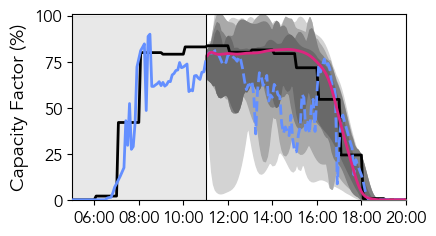

In [13]:
# Confidence bands from focal-curve envelop
def _confidence_bands_from_depth(_depth, F_, alpha_, dt_, N_):    

    # Compute depth to find the focal-curve
    _F = FDataGrid(data_matrix = F_,
                   grid_points = dt_[-F_.shape[1]:])
    
    rank_ = np.argsort(_depth(_F))[::-1]

    _U = {}
    _L = {}
    for i in range(len(alpha_)):
        _U[f'{alpha_[i]}'] = np.max(F_[rank_[:N_[i]], :], axis = 0)
        _L[f'{alpha_[i]}'] = np.min(F_[rank_[:N_[i]], :], axis = 0)
    # Focal-curve
    m_ = F_[rank_[0], :]

    return m_, _L, _U

def _get_depth_samples(depth_, alpha_, time, dist, N):

    N_ = []
    for alpha in alpha_:
        idx_ = (depth_['alpha'] == alpha) & (depth_['distance'] == dist)
        x_ = depth_.loc[idx_, 'fraction'].to_numpy()
        time_ = depth_.loc[idx_].index.to_numpy()
        N_.append(int(np.interp(time, time_, x_)*M_.shape[0]))
    return np.array(N_)

# Samples in each confidence band
alpha_ = [0.1, 0.2, 0.3, 0.4]
depth = 'MBD'
N_ = _get_depth_samples(depth_, alpha_, time, depth, M_.shape[0])

M_interp_, M_interp_ds_, dt_p_ = _functional_downsampling(M_, dt_,
                                                          x_ = f_0_,
                                                          subsample = 12,
                                                          n_basis = int(M_.shape[1]/5)) 

print(M_interp_.shape, M_.shape)
m_, _U, _L = _confidence_bands_from_depth(ModifiedBandDepth(), M_interp_, alpha_, dt_, N_)

_fig, _ax = plt.subplots(figsize = (4.25, 2.25), constrained_layout = True)

_plot_envelop(_ax, _U, _L, f_, f_hat_, e_bias_, m_[1:], dt_, dx_, time, 
              CR = 'CR',
              label = r"$\tilde{f} (s)$",
              color = palette_.loc[2, "ibm"],
              legend_1 = False, 
              legend_2 = False)

_ax.legend(frameon = False, 
           loc = (0.1875, .825),
           fontsize = 12,
           columnspacing=0.5,
           handletextpad=0.25,
           ncol = 5)

plt.savefig(path_to_images + f"/depth-{depth}_{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

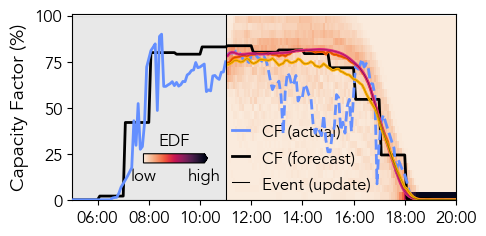

In [14]:
def _plot_density_heatmap(_ax, M_, f_, f_hat_, e_, dx_, dt_, t, 
                          median_curve, central_curve, focal_curve,
                          range_ = [60, 240],
                          colorbar = True,
                          legend_1 = True,
                          legend_2 = True):

    tau_ = dt_[:t]
    s_ = dt_[t:]
    dt = dt_[1] - dt_[0]

    Z_ = []
    for i in range(M_.shape[1]):
        a_, b_ = np.histogram(100 * M_[:, i], 
                              bins = 25, 
                              range = (0, 100), 
                              density = True)
        Z_.append(a_)

    Z_     = np.stack(Z_).T
    X_, Y_ = np.meshgrid(dt_[t:], (b_[1:] + b_[:-1]) / 2.0)

    _cmap = sns.color_palette("rocket_r", as_cmap = True)
    _ax.pcolormesh(X_ + dt, Y_, Z_, cmap = _cmap, alpha = 1.)

    _ax.plot(s_ + dt, 100 * median_curve, 
             c = palette_.loc[3, "ibm"], 
             label = r"$\bar{\mu} (s)$" if legend_2 else None,
             lw = 2, 
             zorder = 10)

    _ax.plot(s_ + dt, 100 * median_curve, 
             c = 'k', 
             lw = .25,
             alpha = 0.5,
             zorder = 11)
    
    _ax.plot(s_ + dt, 100 * central_curve, 
             c = palette_.loc[2, "ibm"], 
             label = r"$\bar{f} (s)$" if legend_2 else None,
             lw = 2, 
             zorder = 10)
    
    _ax.plot(s_ + dt, 100 * central_curve, 
             c = 'k', 
             lw = .25, 
             alpha = 0.5,
             zorder = 11)
    
    _ax.plot(s_ + dt, 100 * focal_curve, 
             c = palette_.loc[4, "ibm"], 
             label = r"$\tilde{f} (s)$" if legend_2 else None,
             lw = 2, 
             zorder = 10)

    _ax.plot(s_ + dt, 100 * focal_curve, 
             c = 'k', 
             lw = .25, 
             alpha = 0.5,
             zorder = 11)
    
    _ax.plot(tau_ + dt, 100 * f_,
             c = palette_.loc[0, "ibm"],
             zorder = 9,
             lw = 2,
             label = "CF (actual)" if legend_1 else None, 
             clip_on = True)

    _ax.plot(s_ + dt, 100 * f_hat_, 
             c = palette_.loc[0, "ibm"], 
             zorder = 9,
             lw = 2, 
             ls = "--", 
             clip_on = True)

    _ax.plot(dt_ + dt, 100 * e_, 
             c = "k", 
             lw = 2, 
             label = "CF (forecast)" if legend_1 else None, 
             zorder = 8,
             clip_on = True)

    _ax.axvline(dt_[t - 1] + dt, 
                color = "k", 
                linewidth = 0.75, 
                label = "Event (update)" if legend_1 else None,
                zorder = 10)

    _ax.fill_between(tau_ + dt, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color = "lightgray",
                     alpha = 0.5)
    
    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation = 0)
    _ax.set_ylabel("Capacity Factor (%)", size = 14)

    _ax.tick_params(axis = "both", labelsize = 12)

    _ax.set_ylim(0, 101)
    _ax.set_xlim(dt_[range_[0]], dt_[range_[-1]])

    if colorbar:
        cbar = fig.colorbar(cm.ScalarMappable(cmap=_cmap),
                            cax = _ax.inset_axes([467.5, 20, 150, 5], transform=_ax.transData),
                            orientation = "horizontal",
                            extend = "max")
    
        cbar.set_ticks([0, 1], 
                       labels = ["low", "high"], 
                       fontsize = 12)
        
        cbar.ax.tick_params(length=0)
    
        cbar.ax.set_title("EDF", rotation=0)

_fig, _ax = plt.subplots(figsize = (4.75, 2.25), constrained_layout = True)

_plot_density_heatmap(_ax, M_, f_, f_hat_, e_bias_, dx_, dt_, time, 
                      median_curve = med_[1:],
                      central_curve = m_[1:],
                      focal_curve = _meta['focal_curve'],
                      colorbar = True,
                      legend_1 = True,
                      legend_2 = False)

_ax.legend(frameon = False, 
           loc = (0.4, 0),
           fontsize = 12, 
           ncol = 1)

plt.savefig(path_to_images + f"/heatmap-{file_name}.pdf", 
            bbox_inches = "tight")

plt.show()

(13162,) (1143,) (175,)


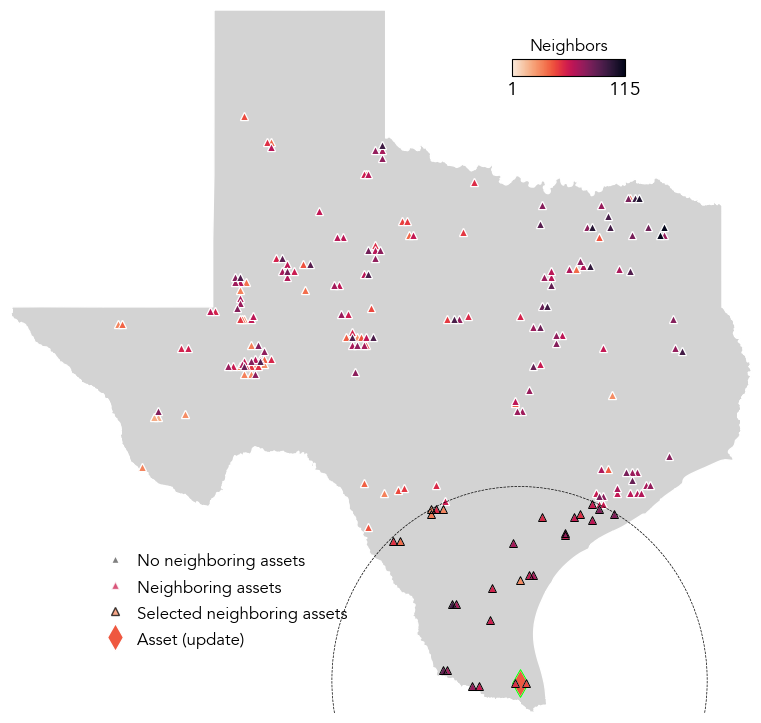

In [15]:
def _plot_frequency_map(_fig, _ax, TX_, x_tr_, x_ts_, x_, idx_nn_, idx_temp_, idx_spatial_, sigma):

    x_tr_p_, z_tr_p_ = np.unique(x_tr_[idx_nn_, :], 
                                 return_counts = True, 
                                 axis = 0)

    _cmap = sns.color_palette("rocket_r", as_cmap=True)
    _norm = plt.Normalize(1, z_tr_p_.max())

    TX_.plot(ax=_ax, 
             facecolor="lightgray", 
             edgecolor="white", 
             zorder=0)

    _ax.plot(x_ts_[:, 0], x_ts_[:, 1],
             c="gray",
             alpha=1,
             ms=6,
             marker="^",
             mec="w",
             ls="none",
             mew=1.0,
             zorder=2, 
             clip_on=False,
             label="No neighboring assets")
    
    _ax.plot(x_[0], x_[1],
             c=_cmap(_norm(z_tr_p_.max() / 2.0)),
             alpha=0.75,
             ms=6,
             ls="none",
             marker="^",
             mec="w",
             mew=1.0,
             zorder=0, 
             clip_on=False,
             label="Neighboring assets")

    _ax.plot(x_[0], x_[1],
             c=_cmap(_norm(z_tr_p_.max() / 4.0)),
             alpha=0.75,
             ms=6,
             ls="none",
             marker="^",
             mec="k",
             mew=1.0,
             zorder=0, 
             clip_on=False,
             label="Selected neighboring assets")

    for i in np.arange(x_tr_p_.shape[0], dtype=int)[np.argsort(z_tr_p_)]:
        if (x_tr_p_[i, 0] != x_[0]) | (x_tr_p_[i, 1] != x_[1]):
            _ax.plot(x_tr_p_[i, 0], x_tr_p_[i, 1],
                     c=_cmap(_norm(z_tr_p_[i])),
                     ms=6,
                     ls="none",
                     marker="^",
                     mec="w",
                     mew=.75,
                     zorder=6, 
                     clip_on=False)
        else:
            _ax.plot(x_tr_p_[i, 0], x_tr_p_[i, 1],
                     c=_cmap(_norm(z_tr_p_[i])),
                     ms=14,
                     ls="none",
                     marker="d",
                     mec="w",
                     mew=1.,
                     zorder=4, 
                     label = 'Asset (update)',
                     clip_on=False)

    x_tr_p_ = np.unique(x_tr_[idx_spatial_, :], axis=0)
    for i in range(x_tr_p_.shape[0]):
        if (x_tr_p_[i, 0] != x_[0]) | (x_tr_p_[i, 1] != x_[1]):
            _ax.plot(x_tr_p_[i, 0], x_tr_p_[i, 1],
                     ms=6,
                     ls="none",
                     marker="^",
                     c = 'none', 
                     mec="k",
                     mew=.75,
                     zorder=7, 
                     clip_on=False)
        else:
            _ax.plot(x_tr_p_[i, 0], x_tr_p_[i, 1],
                     ms=14,
                     ls="none",
                     marker="d",
                     c = 'none', 
                     mec="lime",
                     mew=.75,
                     zorder=5, 
                     #label = 'Asset (update)',
                     clip_on=False)
    
    minx, miny, maxx, maxy = TX_.total_bounds
    X_, Y_ = np.meshgrid(np.linspace(minx, maxx, 1000), 
                         np.linspace(miny, maxy, 1000))
    
    Z_ = _haversine_dist(x_, np.concatenate([X_.flatten()[:, np.newaxis], 
                                             Y_.flatten()[:, np.newaxis]], axis = 1)).reshape(X_.shape)

    contours = _ax.contour(X_, Y_, Z_, 
                           levels = [sigma], 
                           colors = 'k', 
                           linewidths = 0.5, 
                           linestyles = 'dashed', zorder = 11)

    cbar = _fig.colorbar(cm.ScalarMappable(cmap = _cmap),
                         cax=_ax.inset_axes([-97.75, 35.5, 2.0, 0.25], transform = _ax.transData),
                         orientation="horizontal")

    cbar.set_ticks([0, 1], 
                   labels=[1, int(z_tr_p_.max())], 
                   fontsize=14)
    
    cbar.ax.tick_params(length=0)
    
    cbar.ax.set_title("Neighbors", 
                      rotation = 0, 
                      fontsize = 12)


    
    _ax.set_axis_off()

print(_meta['idx_neigbors'].shape, _meta['idx_temporal'].shape, _meta['idx_spatial'].shape)

fig, _ax = plt.subplots(figsize = (7.5, 7.5), constrained_layout = True)

_plot_frequency_map(_fig, _ax, TX_, x_tr_, x_ts_, x_ts_[asset, :], _meta['idx_neigbors'], 
                    _meta['idx_temporal'], _meta['idx_spatial'], _meta['sigma'])

_ax.legend(frameon=False,
           bbox_to_anchor=(0.475, 0.25),
           ncol=1,
           fontsize=12)

# plt.savefig(path_to_images + f"/spatial_neiboring_assets-{file_name}.pdf", 
#             bbox_inches="tight")
plt.show()

 /var/folders/0c/ffx2kgyn7xq4krqrpsv67l3m0000gn/T/ipykernel_50371/961759262.py:91: UserWarning:constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
 /var/folders/0c/ffx2kgyn7xq4krqrpsv67l3m0000gn/T/ipykernel_50371/961759262.py:91: UserWarning:constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning:constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.


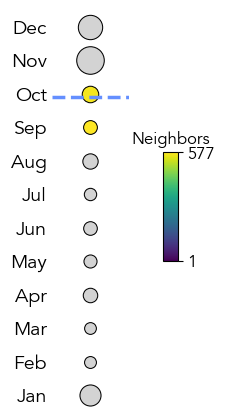

In [16]:
def _scenarios_frequency_dates(_ax, T_tr_, idx_nn_, idx_temp_, idx_spatial_, t_ts, 
                               scale = 2.5,
                               colorbar = True):

    _date     = datetime.datetime.strptime(t_ts, "%Y-%m-%d %H:%M:%S")
    m_a       = _date.timetuple().tm_mon - 1
    day       = _date.timetuple().tm_mday - 1
    _, n_days = calendar.monthrange(_date.year, m_a + 1)

    m_tr_ = np.stack([datetime.datetime.strptime(T_tr_[i], "%Y-%m-%d %H:%M:%S").timetuple().tm_mon - 1
                      for i in range(T_tr_.shape[0])])

    month_name_ = ["Jan", "Feb", "Mar", "Apr",
                   "May", "Jun", "Jul", "Aug",
                   "Sep", "Oct", "Nov", "Dec"]
    
    months_, counts_ = np.unique(m_tr_[idx_nn_], return_counts=True)

    counts_1_ = np.zeros(12)
    for month, count in zip(months_, counts_):
        counts_1_[month] = count
    
    months_, counts_ = np.unique(m_tr_[idx_temp_], return_counts=True)

    counts_2_ = np.zeros(12)
    for month, count in zip(months_, counts_):
        counts_2_[month] = count

    months_ = np.arange(12, dtype = int)
    jitter_strength = 0.5
    x_ = 0. + np.random.normal(0, jitter_strength, size=months_.shape[0])*0.

    counts_2_p_ = counts_2_.copy()
    counts_2_p_[counts_2_ == 0] = np.nan

    _cmap = sns.color_palette("viridis", as_cmap=True)
    _cmap.set_bad(color= 'lightgray')  # RGBA: transparent
    _norm = plt.Normalize(1, counts_2_.max())
    
    for i in range(x_.shape[0]):
        # Plot
        _ax.scatter(x_[i], months_[i], 
                    s=counts_1_[i]*scale,
                    color=_cmap(_norm(counts_2_p_[i])),
                    ec='k',
                    vmin=1, 
                    vmax=counts_2_.max(),
                    lw=0.75, 
                    clip_on = False,
                    zorder = 6)

    _ax.set_xlim(-5, 5)

    _ax.set_xticks(x_, []*len(x_))
        
    _ax.set_yticks(np.arange(len(month_name_), dtype=int), month_name_,
                   size=14)
    
    _ax.tick_params(axis='y', length=0)
    _ax.tick_params(axis='x', length=0)

    _ax.axhline(m_a + day/n_days, 
                color=palette_.loc[0, "ibm"], 
                ls = '--',
                lw=2.5, 
                zorder=6)
    
    cbar = _fig.colorbar(cm.ScalarMappable(cmap = _cmap),
                         cax=_ax.inset_axes([7.5, 4, 1.5, 3.25], transform = _ax.transData))

    cbar.set_ticks([0, 1], 
                   labels=[1, int(counts_2_.max())], 
                   fontsize=12)
        
    cbar.ax.set_title("Neighbors", 
                      rotation = 0, 
                      fontsize = 12)
    _ax.set_xlim(-4, 4)

    sns.despine(left=True, 
                bottom=True) 

fig, _ax = plt.subplots(figsize = (1, 5), constrained_layout = True)


_scenarios_frequency_dates(_ax, T_tr_[:, time], _meta['idx_neigbors'], _meta['idx_temporal'], 
                           _meta['idx_spatial'], T_ts_[day, time], 
                           scale = .1375,
                           colorbar = True)

plt.savefig(path_to_images + f"/temporal_neiboring_assets-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

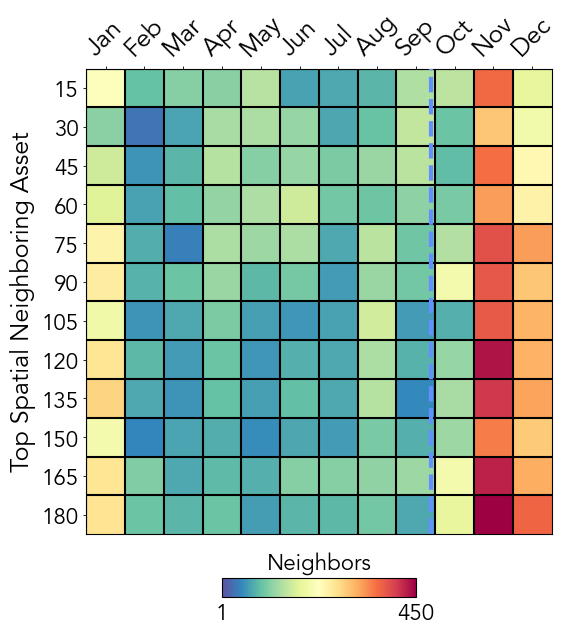

In [17]:
def _selected_scenarios_heatmap(_ax, T_tr_, d_h_, x_ts_, x_, idx_, t_ts, 
                                colorbar = True):

    N     = 12
    delta = 15

    d_      = _haversine_dist(x_, x_ts_)
    d_sort_ = np.sort(d_)[:-7]

    tops_      = [int((i + 1) * delta) for i in range(N)]
    intervals_ = [d_sort_[i - 1] for i in tops_]

    _date     = datetime.datetime.strptime(t_ts, "%Y-%m-%d %H:%M:%S")
    m_a       = _date.timetuple().tm_mon - 1
    day       = _date.timetuple().tm_mday - 1
    _, n_days = calendar.monthrange(_date.year, m_a + 1)

    m_tr_ = np.stack([datetime.datetime.strptime(T_tr_[i], "%Y-%m-%d %H:%M:%S").timetuple().tm_mon - 1
                      for i in range(T_tr_.shape[0])])

    K        = 0
    heatmap_ = np.zeros((N + 1, m_tr_.max() + 1))
    for d_h, m in zip(d_h_[idx_], m_tr_[idx_]):
        heatmap_[np.searchsorted(intervals_, d_h), m] += 1
        K += 1
        
    h_max = int(heatmap_.max())
    heatmap_[heatmap_ == 0.] = np.nan

    _cmap = sns.color_palette("Spectral_r", as_cmap=True)
    _cmap.set_bad(color= 'lightgray')  # RGBA: transparent
    
    month_ = ["Jan",
              "Feb",
              "Mar",
              "Apr",
              "May",
              "Jun",
              "Jul",
              "Aug",
              "Sep",
              "Oct",
              "Nov",
              "Dec"]

    _ax.matshow(heatmap_[:-1, :], 
                cmap=_cmap, 
                vmin=0.0, 
                extent=[0, 12, N, 0])

    _ax.set_xticks(range(len(month_)), [] * len(month_))
    _ax.set_yticks(range(len(tops_)), [] * len(tops_))

    _ax.set_ylabel("Top Spatial Neighboring Asset", size=18)
    
    # if xlabel:
    #     _ax.set_xlabel("Month", size=16)
    _ax.xaxis.set_label_position("top")

    _ax.set_xticks(np.arange(len(month_), dtype=int) + 0.5, month_,
                   rotation=45,
                   minor=True,
                   size=18)

    _ax.set_yticks(np.arange(len(tops_), dtype=int) + 0.5, tops_,
                   minor=True,
                   size=16)

    _ax.tick_params(which="major", 
                    bottom=False, 
                    left=False, 
                    top=False)
    
    _ax.tick_params(which="minor", 
                    bottom=False)
    
    _ax.grid(which="major", 
             color="k", 
             linestyle="-", 
             linewidth=1.5)

    _ax.axvline(m_a + day/n_days, 
                color=palette_.loc[0, "ibm"], 
                ls = '--',
                lw=3, 
                zorder=6)
    
    if colorbar:
        cbar = _fig.colorbar(cm.ScalarMappable(cmap = _cmap),
                             cax = _ax.inset_axes([3.5, 13.125, 5., 0.5], transform = _ax.transData),
                             orientation="horizontal")
    
        cbar.set_ticks([0, 1], 
                       labels=[1, h_max], 
                       fontsize=16)
        
        cbar.ax.tick_params(length=0)
        
        cbar.ax.set_title("Neighbors", 
                          rotation = 0, 
                          fontsize = 16)

fig, _ax = plt.subplots(figsize = (7.5, 6.25), constrained_layout = True)

_selected_scenarios_heatmap(_ax, T_tr_[:, time], _meta['d_h'], x_ts_, x_ts_[asset, :], _meta['idx_neigbors'], T_ts_[day, time], 
                            colorbar = True)

plt.savefig(path_to_images + f"/seasonly_neiboring_assets-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

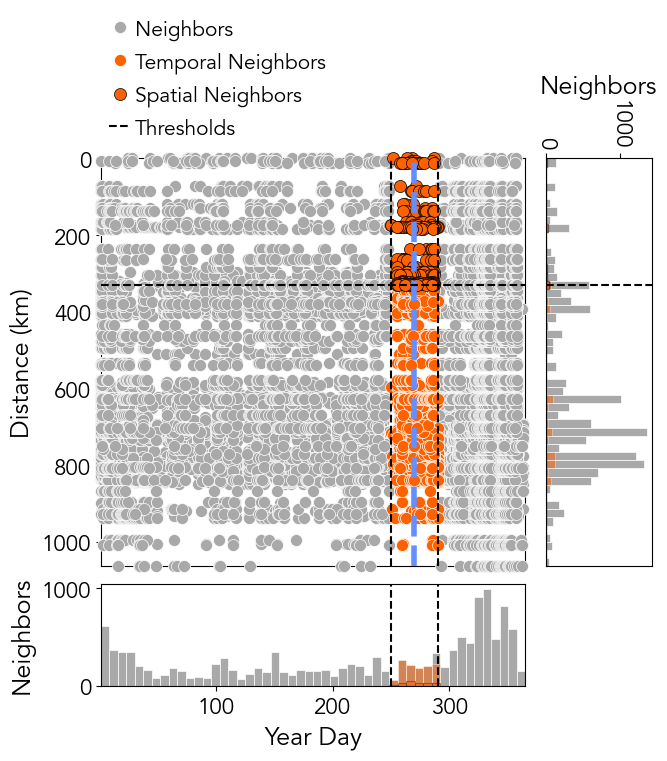

In [18]:
def _plot_scenario_filtering(_ax, d_h_, t_tr_, idx_nn_, idx_temp_, idx_spatial_, 
                             t_ts, Gamma, gamma, sigma):

    def __check_limit(x):
        if x > 365:
            x = x - 365
        if x < 1:
            x = x + 365
        return x

    _ax.scatter(t_tr_[idx_nn_], d_h_[idx_nn_],
                s=75,
                c="darkgray",
                lw=0.5,
                edgecolor="w",
                clip_on=False,
                zorder=4,
                label="Neighbors")

    _ax.scatter(t_tr_[idx_temp_], d_h_[idx_temp_],
                s=75,
                c=palette_.loc[3, "ibm"],
                lw=0.5,
                edgecolor="w",
                clip_on=False,
                zorder=5,
                label="Temporal Neighbors")

    _ax.scatter(t_tr_[idx_spatial_], d_h_[idx_spatial_],
                s=75,
                c=palette_.loc[3, "ibm"],
                lw=0.5,
                edgecolor="k",
                clip_on=False,
                zorder=5,
                label="Spatial Neighbors")

    _ax.axvline(t_ts, 
                color=palette_.loc[0, "ibm"], 
                ls = '--',
                lw=4, 
                zorder=6)

    if Gamma != 0:  
        _ax.axvline(__check_limit(t_ts + gamma), 
                    c="k", 
                    ls='--', 
                    lw=1.5, 
                    zorder=10)
                    
        _ax.axvline(__check_limit(t_ts - gamma), 
                    c="k", 
                    ls='--', 
                    lw=1.5, 
                    zorder=10, 
                    label="Thresholds")
    
    if sigma != 0:
        _ax.axhline(sigma, 
                    c="k", 
                    ls='--', 
                    lw=1.5, 
                    zorder=10)

    #_ax.set_ylabel(r"$|| \mathbf{x}_\star - \mathbf{x}_n ||_\mathrm{H}$", size=14)
    #_ax.set_xlabel(r"$|| d_\star - d_n ||_\mathrm{p}$", size=16)
    #_ax.set_xlabel(r"Year Day", size=16)
    _ax.set_ylabel(r"Distance (km)", size=18)
    _ax.set_xlim(1, 365)
    _ax.set_ylim(0, d_h_.max())
    _ax.set_xticks([], [])

    _ax.tick_params(axis="both", 
                    labelsize=16)

    _ax.set_xlim(1, 365)
    _ax.invert_yaxis()


def _plot_dates_histogram(_ax, t_tr_, idx_nn_, idx_temp_, idx_spatial_, t_ts, Gamma, gamma):

    def __check_limit(x):
        if x > 365:
            x = x - 365
        if x < 1:
            x = x + 365
        return x

    _ax.hist(t_tr_[idx_nn_], 
             bins=50, 
             range=(1, 365), 
             color="darkgray", 
             edgecolor="w", 
             lw=0.5)

    _ax.hist(t_tr_[idx_temp_],
             bins=50,
             range=(1, 365),
             alpha=0.5,
             color=palette_.loc[3, "ibm"],
             edgecolor="w",
             lw=0.5)

    _ax.hist(t_tr_[idx_spatial_],
             bins=50,
             range=(0, 365),    
             alpha=0.5,
             color=palette_.loc[3, "ibm"],
             edgecolor="k",
             lw=0.5)
    
    if Gamma != 0:  
        _ax.axvline(__check_limit(t_ts - gamma), 
                    c="k", 
                    ls="--", 
                    lw=1.5, 
                    zorder=2, 
                    label="d: day")
        
        _ax.axvline(__check_limit(t_ts + gamma), 
                    c="k", 
                    ls="--", 
                    lw=1.5, 
                    zorder=2, 
                    label="d: day")
        
    _ax.set_xlabel(r"Year Day", size=18)
    _ax.set_ylabel(r"Neighbors", size=18)
    _ax.set_xlim(1, 365)
    _ax.tick_params(axis="both", labelsize=16)
    #_ax.set_xticks([], [])

def _plot_distance_histogram(_ax, d_h_, idx_nn_, idx_temp_, idx_spatial_, sigma):

    d_max = d_h_.max()
    
    _ax.hist(d_h_[idx_nn_], 
             bins=50, 
             range=(0, d_max), 
             color="darkgray", 
             edgecolor="w", 
             lw=0.5, 
             orientation="horizontal")
    
    _ax.hist(d_h_[idx_temp_],
             bins=50,
             range=(0, d_h_.max()),    
             alpha=0.5,
             color=palette_.loc[3, "ibm"],
             edgecolor="w",
             lw=0.5, 
             orientation="horizontal")

    _ax.hist(d_h_[idx_spatial_],
             bins=50,
             range=(0, d_h_.max()),    
             alpha=0.5,
             color=palette_.loc[3, "ibm"],
             edgecolor="k",
             lw=1, 
             orientation="horizontal")

    if sigma != 0:
        _ax.axhline(sigma, 
                    c="k", 
                    ls='--', 
                    lw=1.5, 
                    zorder=10)

    _ax.xaxis.set_label_position("top")
    _ax.xaxis.tick_top()
    #_ax.set_xlabel(r"Distance (km)", size=16)
    _ax.set_xlabel(r"Neighbors", size=18)
    _ax.set_ylim(0, d_max)
    _ax.tick_params(axis="both", labelsize=16, rotation = 270)
    _ax.set_yticks([], [])
    _ax.invert_yaxis()
    #_ax.legend(frameon=False, ncol=1, fontsize = 12)

fig, _ax = plt.subplot_mosaic([["A", "B"], 
                               ["C", "."]],
                              figsize = (6.5, 7.5),
                              layout = "constrained",
                              gridspec_kw = dict(width_ratios  = (1, .25), 
                                                 height_ratios = (1, .25)))


_plot_scenario_filtering(_ax["A"], 
                         _meta['d_h'], 
                         t_tr_, 
                         _meta['idx_neigbors'], 
                         _meta['idx_temporal'], 
                         _meta['idx_spatial'], 
                         t_ts_[day], 
                         _meta['Gamma'], 
                         _meta['gamma'], 
                         _meta['sigma'])

_plot_distance_histogram(_ax["B"], 
                         _meta['d_h'], 
                         _meta['idx_neigbors'], 
                         _meta['idx_temporal'], 
                         _meta['idx_spatial'],
                         _meta['sigma'])

_plot_dates_histogram(_ax["C"], 
                      t_tr_, 
                      _meta['idx_neigbors'], 
                      _meta['idx_temporal'], 
                      _meta['idx_spatial'], 
                      t_ts_[day], 
                      _meta['Gamma'], 
                      _meta['gamma'])

_ax["A"].legend(frameon=False, 
                ncol=1, 
                columnspacing=0.625,
                handletextpad=0.25,
                loc = (0., 1.025), 
                fontsize = 15)

plt.savefig(path_to_images + f"/kNN_frequency-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

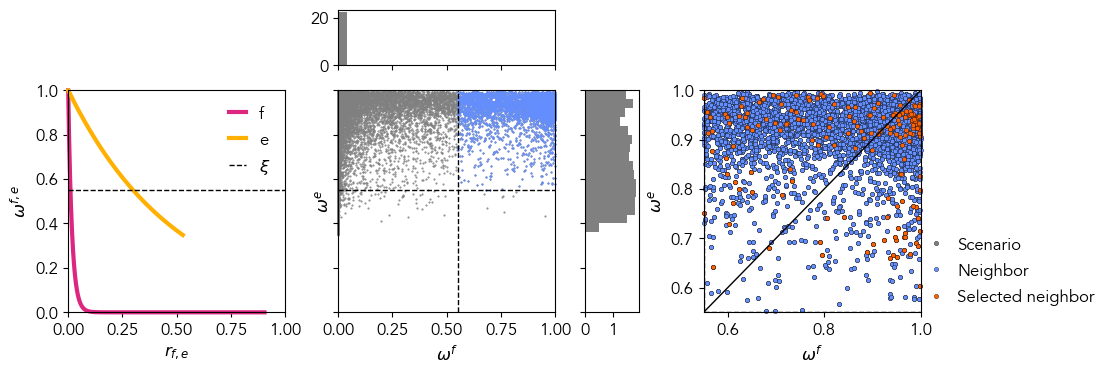

In [23]:
def _plot_density_threshold(_ax, d_f_, d_e_, w_f_, w_e_, xi):

    _ax.plot(d_f_[np.argsort(d_f_)], w_f_[np.argsort(d_f_)],
             c=palette_.loc[2, "ibm"],
             lw=3,
             label="f", 
             clip_on = False)

    _ax.plot(d_e_[np.argsort(d_e_)], w_e_[np.argsort(d_e_)],
             c=palette_.loc[4, "ibm"],
             lw=3,
             label="e", 
             clip_on = False)

    _ax.axhline(xi, 
                ls="--", 
                color="k", 
                lw=1.0, 
                label=r"$\xi$", 
                zorder=10)
    
    _ax.set_ylabel(r"$\omega^{f,e}$", size=12)
    _ax.set_xlabel(r"$r_{f,e}$", size=12)
    
    _ax.tick_params(axis="both", 
                    labelsize=12)
    
    _ax.legend(frameon=False, 
               fontsize=12)

    _ax.set_ylim(0, 1)
    _ax.set_xlim(0, 1)

    
def _plot_fneighborhood(_ax, _ax_top, _ax_left, w_f_, w_e_, idx_nn_, xi):

    _ax.scatter(w_f_, w_e_, 
                color="gray", 
                s=0.25, 
                zorder=1, 
                clip_on = False)

    _ax.scatter(w_f_[idx_nn_], w_e_[idx_nn_], 
                c=palette_.loc[0, "ibm"],
                s=0.25, 
                zorder=2, 
                clip_on = False)

    _ax.axhline(xi, 
                ls="--", 
                color="k", 
                lw=1.0, 
                label=r"$\xi$", 
                zorder=10)

    _ax.axvline(xi, 
                ls="--", 
                color="k", 
                lw=1.0, 
                label=r"$\xi$", 
                zorder=10)

    _ax.set_ylabel(r"$\omega^{e}$", size=12)
    _ax.set_xlabel(r"$\omega^{f}$", size=12)
    
    _ax.tick_params(axis="both", labelsize=12)

    _ax.set_ylim(0, 1)
    _ax.set_xlim(0, 1)

    _ax_top.hist(w_f_, 
                 bins=25, 
                 range=(0, 1),
                 color="gray", 
                 density=True)

    # _ax_top.hist(w_f_[idx_nn_], 
    #              bins=25, 
    #              range=(0, 1),
    #              color=palette_.loc[0, "ibm"], 
    #              density=False)
    
    _ax_top.tick_params(axis="both", 
                        labelsize=12)
    
    _ax_top.set_xlim(0, 1)

    _ax_left.hist(w_e_, 
                  bins=25, 
                  range=(0, 1),
                  color="gray", 
                  density=True, 
                  orientation="horizontal")

    # _ax_left.hist(w_e_[idx_nn_], 
    #               bins=25, 
    #               range=(0, 1),
    #               color=palette_.loc[0, "ibm"], 
    #               density=True, 
    #               orientation="horizontal")
    
    _ax_left.set_ylim(0, 1)

    _ax_left.tick_params(axis="both", 
                         labelsize=12)

    _ax.tick_params(axis="y", 
                    labelleft=False)

    _ax_top.tick_params(axis="x", 
                        labelbottom=False)
    
    _ax_left.tick_params(axis="y", 
                         labelleft=False)
    
def _plot_selection(_ax, w_f_, w_e_, w_, idx_neigbors_, idx_temporal_, idx_spatial_, xi):

    _ax.scatter(w_f_, w_e_, 
                c="gray", 
                s=10, 
                alpha=1.0,
                lw=0.25, 
                ec="k", 
                label="Scenario", 
                clip_on = True)

    _ax.scatter(w_f_[idx_neigbors_], w_e_[idx_neigbors_],
                c=palette_.loc[0, "ibm"],
                s=10,
                alpha=1.0,
                lw=0.25,
                ec="k",
                label="Neighbor",
                clip_on = False)

    _ax.scatter(w_f_[idx_spatial_], w_e_[idx_spatial_],
                c=palette_.loc[3, "ibm"],
                s=10,
                lw=0.25,
                ec="k",
                alpha=1.0,
                label="Selected neighbor", 
                clip_on = False)

    _ax.axline((1, 1), 
               slope=1, 
               lw=1, 
               c="k")
    
    _ax.set_ylabel(r"$\omega^{e}$", size=12)
    _ax.set_xlabel(r"$\omega^{f}$", size=12)
    
    _ax.tick_params(axis="both", 
                    labelsize=12)
    
    _ax.set_xlim(xi, 1)
    _ax.set_ylim(xi, 1)
    
    _ax.axhline(xi, 
                ls="--", 
                color="k", 
                lw=1.0, 
                zorder=10)
    
    _ax.axvline(xi, 
                ls="--", 
                color="k", 
                lw=1.0, 
                zorder=10)
    
    _ax.legend(frameon=False, 
               fontsize=12, 
               ncol=1, 
               loc=(1., 0.))

  
fig, _ax = plt.subplot_mosaic([[".", ".", "e", ".", ".", "."],
                               ["A", "A", "B", "f", "C", "C"],
                               ["A", "A", "B", "f", "C", "C"]],
                               figsize = (11, 3.625),
                               layout = "constrained",
                               gridspec_kw = dict(width_ratios  = (2, 2, 4, 1, 2, 2), 
                                                  height_ratios = (1, 2, 2)))

_plot_density_threshold(_ax["A"], 
                        _meta['d_f'], 
                        _meta['d_e'], 
                        _meta['w_f'], 
                        _meta['w_e'], 
                        _meta['xi'])

_plot_fneighborhood(_ax["B"], 
                    _ax["e"], 
                    _ax["f"], 
                    _meta['w_f'], 
                    _meta['w_e'], 
                    _meta['idx_neigbors'], 
                    _meta['xi'])

_plot_selection(_ax["C"],  
                _meta['w_f'], 
                _meta['w_e'], 
                _meta['w'], 
                _meta['idx_neigbors'], 
                _meta['idx_temporal'], 
                _meta['idx_spatial'], 
                _meta['xi'])

plt.savefig(path_to_images + f"/fneighbor-{file_name}.pdf", 
            bbox_inches = "tight")

plt.show()

(76593, 288) (76593, 288) (76593, 288)


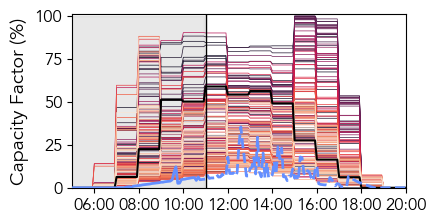

In [24]:
def _plot_forecasts(_ax, E_tr_, f_, f_hat_, e_, w_, idx_, dx_, dt_, t, 
                    legend = False,
                    range_ = [60, 240]):

    tau_ = dt_[:t]
    s_   = dt_[t:]

    z_   = (w_ - w_[idx_].min()) / (w_[idx_].max() - w_[idx_].min())
    idx_ = idx_[np.argsort(w_[idx_])]

    _cmap = sns.color_palette("rocket", as_cmap=True)
    _norm = plt.Normalize(0, 1)

    _ax.plot([], [], 
             lw = 0.75,
             label=r"$E_{\star} \left([\tau, s]\right)$", 
             c="k")
    
    _ax.plot(tau_, 100 * f_,
             c=palette_.loc[0, "ibm"],
             clip_on=True,
             zorder=10,
             #label="CF (ac)",
             lw=2)

    _ax.plot(s_, 100 * f_hat_,
             c=palette_.loc[0, "ibm"],
             clip_on=True,
             zorder=10,
             lw=2,
             ls="--")

    _ax.plot(dt_, 100 * e_, 
             clip_on=True, 
             lw=1.5, 
             zorder=9, 
             #label="CF (fc)", 
             c="k")

    for i, j in zip(idx_, range(idx_.shape[0])):
        _ax.plot(dt_, 100 * E_tr_[i, :], 
                 #c=_cmap(_norm(z_[i])), 
                 c=_cmap(_norm(j/idx_.shape[0])), 
                 lw=.5, 
                 zorder=8)

    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color="lightgray",
                     alpha=0.5,
                     zorder=1)
    
    _ax.axvline(dt_[t], 
                color="k", 
                lw=1.0, 
                zorder=11)
    
    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation=0)

    _ax.set_ylim(0, 101)
    _ax.set_xlim(dt_[range_[0]], dt_[range_[-1]])
    _ax.set_ylabel("Capacity Factor (%)", size=14)

    _ax.tick_params(axis="both", 
                    labelsize=12)

_fig, _ax = plt.subplots(figsize = (4.25, 2.125), constrained_layout = True)
print(E_tr_.shape, E_tr_lin_.shape, E_tr_bias_.shape)

_plot_forecasts(_ax, E_tr_bias_, f_, f_hat_, e_bias_, _meta['w'], _meta['idx_spatial'], dx_, dt_, time)

# _ax.legend(loc=(0.5, 0.8),
#            frameon=False, 
#            fontsize=12, 
#            ncol=1)

plt.savefig(path_to_images + f"/dayahead_neighbors-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

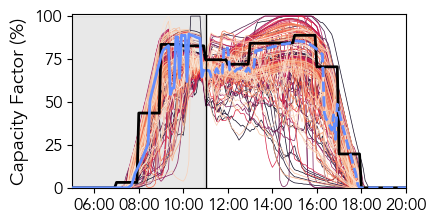

In [54]:
def _plot_neighbors(_ax, F_tr_, f_, f_hat_, e_, w_, idx_, dx_, dt_, t,
                    range_ = [60, 240]):

    tau_ = dt_[:t]
    s_   = dt_[t:]

    z_   = (w_ - w_[idx_].min()) / (w_[idx_].max() - w_[idx_].min())
    idx_ = idx_[np.argsort(w_[idx_])]

    _cmap = sns.color_palette("rocket", as_cmap=True)
    _norm = plt.Normalize(0., 1.)

    _ax.plot([], [], 
             lw = 0.75,
             label=r"$\mathcal{F}_{\star} \left([\tau, s] \right)$", 
             c="k")
    
    _ax.plot(tau_, 100 * f_, 
             c=palette_.loc[0, "ibm"], 
             zorder=10, 
             #label="CF (ac)", 
             lw=2, 
             clip_on = True)

    _ax.plot(s_, 100 * f_hat_, 
             c=palette_.loc[0, "ibm"], 
             zorder=10, 
             lw=2, 
             ls="--", 
             clip_on = True)

    _ax.plot(dt_, 100 * e_, 
             lw=2, 
             zorder=9, 
             #label="CF (fc)", 
             c="k", 
             clip_on = True)

    for i, j in zip(idx_, range(idx_.shape[0])):
        _ax.plot(dt_, 100 * F_tr_[i, :], 
                 c=_cmap(_norm(j/idx_.shape[0])), 
                 #c=_cmap(_norm(z_[i])), 
                 lw=.5, 
                 zorder=8)

    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color="lightgray",
                     alpha=0.5,
                     zorder=1)

    _ax.axvline(dt_[t], 
                color="k", 
                lw=1.0, 
                zorder=11)
    
    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation=0)
    _ax.set_ylim(0, 101)
    _ax.set_xlim(dt_[range_[0]], dt_[range_[-1]])
    _ax.set_ylabel("Capacity Factor (%)", size=14)

    _ax.tick_params(axis="both", 
                    labelsize=12)

_fig, _ax = plt.subplots(figsize = (4.25, 2.125), constrained_layout = True)

_plot_neighbors(_ax, F_tr_, f_, f_hat_, e_bias_, _meta['w'], _meta['idx_spatial'], dx_, dt_, time)

# _ax.legend(loc=(0.5, 0.8),
#            frameon=False, 
#            fontsize=12, 
#            ncol=1)

plt.savefig(path_to_images + f"/partial_neighbors-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

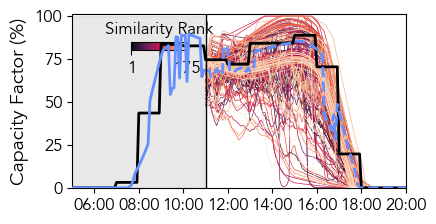

In [55]:
def _plot_updates(_fig, _ax, M_, f_, f_hat_, e_, w_, idx_, dx_, dt_, t,
                  range_ = [60, 240]):

    tau_ = dt_[:t]
    s_   = dt_[t:]
    z_   = (w_ - w_[idx_].min()) / (w_[idx_].max() - w_[idx_].min())
    
    w_selected_ = w_[idx_]
    
    idx_w_ = np.argsort(w_selected_)
    idx_   = idx_[idx_w_]
    
    _cmap = sns.color_palette("rocket", as_cmap=True)
    _norm = plt.Normalize(0., 1)

    _ax.plot([], [], 
             lw = 0.75,
             label=r"$\hat{\mu}_i(s)$", 
             c="k")

    _ax.plot(tau_, 100 * f_,
             c=palette_.loc[0, "ibm"],
             zorder=10,
             #label="CF (ac)",
             clip_on=True,
             lw=2)

    _ax.plot(s_, 100 * f_hat_,
             c=palette_.loc[0, "ibm"],
             zorder=10,
             lw=2,
             clip_on=True,
             ls="--")

    _ax.plot(dt_, 100 * e_, 
             lw=2, 
             zorder=9, 
             #label="CF (fc)", 
             clip_on=True, 
             c="k")

    for i, j in zip(idx_, range(idx_.shape[0])):
        _ax.plot(dt_[t:], 100 * M_[j, :],
                 #c=_cmap(_norm(z_[i])), 
                 c=_cmap(_norm(j/idx_.shape[0])), 
                 lw=0.5, 
                 zorder=8)
        
    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color="lightgray",
                     alpha=0.5,
                     zorder=1)

    _ax.axvline(dt_[t], 
                color="k", 
                lw=1.0, 
                #label="Event (update)", 
                zorder=11)
    
    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation=0)
    # ax_[2].set_yticks(size = 12)
    _ax.set_ylim(0, 101)
    _ax.set_xlim(dt_[range_[0]], dt_[range_[-1]])
    _ax.set_ylabel("Capacity Factor (%)", size=14)
    
    _ax.tick_params(axis="both", 
                    labelsize=12)

    cbar = _fig.colorbar(cm.ScalarMappable(_norm, _cmap),
                         cax=_ax.inset_axes([460, 80, 150, 5], transform=_ax.transData),
                         orientation="horizontal")

    cbar.set_ticks([0, 1], 
                   labels=[1, M_.shape[0]], 
                   size=12)
    
    #cbar.ax.tick_params(length=0)
    
    cbar.ax.set_title("Similarity Rank", 
                      rotation=0, 
                      size=12)

_fig, _ax = plt.subplots(figsize = (4.25, 2.125), constrained_layout = True)

_plot_updates(_fig, _ax, M_, f_, f_hat_, e_bias_, _meta['w'], _meta['idx_spatial'], dx_, dt_, time)

# _ax.legend(loc=(0.5, 0.8),
#            frameon=False, 
#            fontsize=12, 
#            ncol=1)

plt.savefig(path_to_images + f"/dynamic_update_neighbors-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

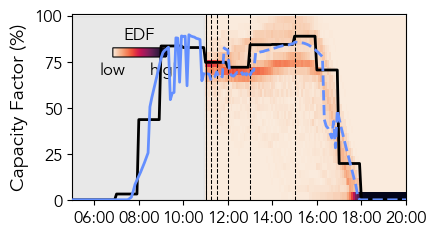

In [56]:
def _plot_heatmap_slices(_fig, _ax, M_, f_, f_hat_, e_, dx_, dt_, t, slices_,
                         range_ = [60, 240],
                         colorbar = True):

    tau_ = dt_[:t]
    s_   = dt_[t:]

    Z_ = []
    for i in range(M_.shape[1]):
        a_, b_ = np.histogram(100.0 * M_[:, i], 
                              bins=25, 
                              range=(0, 100), 
                              density=True)
        Z_.append(a_)

    Z_ = np.stack(Z_).T
    X_, Y_ = np.meshgrid(dt_[t:], (b_[1:] + b_[:-1]) / 2.0)

    _cmap = sns.color_palette("rocket_r", as_cmap=True)
    _ax.pcolormesh(X_, Y_, Z_, cmap =_cmap)

    _ax.plot(tau_, 100 * f_,
             c=palette_.loc[0, "ibm"],
             clip_on=True,
             lw=2.0,
             label="CF (actual)", 
             zorder = 9)

    _ax.plot(s_, 100 * f_hat_, 
             c=palette_.loc[0, "ibm"], 
             clip_on=True, 
             lw=2.0, 
             ls="--", 
             zorder = 9)

    _ax.plot(dt_, 100 * e_, 
             c="k", 
             lw=2.0, 
             label="CF (forecast)", 
             clip_on=True, 
             zorder = 8)
    
    _ax.axvline(dt_[t], 
                color="k", 
                lw=0.75, 
                ls="--", 
                label="Detail")

    for slice in slices_:
        _ax.axvline(dt_[t + slice], 
                    color="k", 
                    lw=0.75, 
                    ls="--")

    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color="lightgray",
                     alpha=0.5)

    _ax.axvline(dt_[t], 
                color="k", 
                label="Event (update)",
                linewidth=0.75, 
                zorder = 11)
    
    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation=0)
    _ax.set_ylabel("Capacity Factor (%)", size=14)

    _ax.tick_params(axis="both", labelsize=12)

    _ax.set_ylim(0, 101)
    _ax.set_xlim(dt_[range_[0]], dt_[range_[-1]])

    if colorbar:
        cbar = _fig.colorbar(cm.ScalarMappable(cmap=_cmap),
                             cax=_ax.inset_axes([410, 77.5, 150, 5], transform=_ax.transData),
                             orientation="horizontal",
                             extend="max")
    
        cbar.set_ticks([0, 1], labels=["low", "high"], fontsize = 12)
        cbar.ax.tick_params(length=0)
    
        cbar.ax.set_title("EDF", rotation=0)

slices_ = [3, 6, 12, 24, 48]

_fig, _ax = plt.subplots(figsize = (4.25, 2.25), constrained_layout = True)

_plot_heatmap_slices(_fig, _ax, M_, f_, f_hat_, e_bias_, dx_, dt_, time, slices_)

# _ax.legend(loc=(0.0725, 1),
#            frameon=False, 
#            fontsize=12, 
#            ncol=4)

plt.savefig(path_to_images + f"/heatmap-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

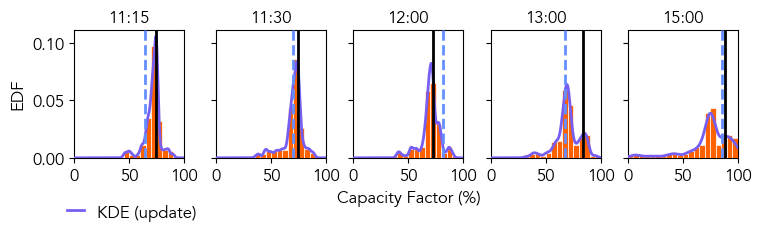

In [57]:
def _plot_histogram_cuts(_ax, KDs_, M_, f_, f_hat_, e_, dx_, dt_, t, slices_):

    tau_ = dt_[:t]
    s_ = dt_[t:]

    x_ = np.linspace(0, 100, 1000)[:, np.newaxis]

    for slice, i in zip(slices_, range(len(slices_))):
        z_ = np.exp(KDs_[slice].score_samples(x_))

        _ax[i].axvline(100 * f_hat_[slice],
                       color=palette_.loc[0, "ibm"],
                       lw=2,
                       ls="--",
                       #label="CF (actual)",
                       zorder=10)

        _ax[i].axvline(100 * e_[t + slice], 
                       color="k", 
                       lw=2, 
                       #label="CF (forecast)", 
                       zorder=10)

        _ax[i].hist(100 * M_[:, slice],
                    bins=20,
                    range=(0, 100),
                    density=True,
                    color=palette_.loc[3, "ibm"], clip_on = True,
                    zorder=8, 
                    edgecolor='w', 
                    linewidth=.5)

        _ax[i].plot(x_, z_,
                    label="KDE (update)",
                    color=palette_.loc[1, "ibm"],
                    lw=2,
                    zorder=9)

        _ax[i].set_title(dx_[t:][slice], size=12)
        _ax[i].set_xlim(0, 100)
        _ax[i].set_ylim(0,)
        
        
        _ax[i].tick_params(axis="both",
                           labelsize=12)

    _ax[0].set_ylabel("EDF", size=12)
    _ax[2].set_xlabel("Capacity Factor (%)", size=12)

    _ax[0].legend(frameon=False, 
                   fontsize=12, loc = (-.125, -0.55))

slices_ = [3, 6, 12, 24, 48]
KDs_ = [KernelDensity(bandwidth = max(_silverman_rule(100 * M_[:, i]), 1e-6), 
                      algorithm = "auto", 
                      kernel = "gaussian").fit(100 * M_[:, i][:, np.newaxis]) for i in range(M_.shape[1])]
    
_fig, _ax = plt.subplots(1, len(slices_), 
                         figsize=(7.5, 2.25), 
                         sharey=True, 
                         layout="constrained")

_plot_histogram_cuts(_ax, KDs_, M_, f_, f_hat_, e_bias_, dx_, dt_, time, slices_)

plt.savefig(path_to_images + f"/marginal_density_cutoffs-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

In [66]:
F_curves_ = []
M_curves_ = []
D_curves_ = []
for time in range(120, 168, 1):
    f_ = F_ts_[day, :time, asset]
    f_hat_ = F_ts_[day, time:, asset]
    e_ = E_ts_[day, :, asset]
    e_lin_ = E_ts_lin_[day, :, asset]
    e_bias_ = E_ts_bias_[day, :, asset]
    x_ts = x_ts_[asset, :]
    t_ts = t_ts_[day]
    
    # Filter solar hours with loading solar set
    idx_days_ = np.absolute(t_tr_ - day) < 7
    idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) + np.sum(E_tr_bias_[idx_days_, :], axis = 0)) > 1.
    
    _meta, M_ = _fknn_forecast_dynamic_update(F_tr_, E_tr_lin_, x_tr_, t_tr_, dt_, f_, e_lin_, x_ts, t_ts,
                                              forget_rate_f = _get_hyper(hyper_, 'forget_rate_f', time),
                                              forget_rate_e = _get_hyper(hyper_, 'forget_rate_e', time),
                                              length_scale_f = _get_hyper(hyper_, 'length_scale_f', time),
                                              length_scale_e = _get_hyper(hyper_, 'length_scale_e', time),
                                              lookup_rate = _get_hyper(hyper_, 'lookup_rate', time),
                                              trust_rate = _get_hyper(hyper_, 'trust_rate', time),
                                              nu = _get_hyper(hyper_, 'nu', time),
                                              gamma = _get_hyper(hyper_, 'gamma', time),
                                              xi = _get_hyper(hyper_, 'xi', time),
                                              kappa = _get_hyper(hyper_, 'kappa', time),
                                              p_fusion = _get_hyper(hyper_, 'p_fusion', time),
                                              idx_hours_ = idx_hours_)

    # Compute depth to find the focal curve
    _F = FDataGrid(data_matrix = M_,
                   grid_points = dt_[time:])

    rank_ = np.argsort(ModifiedBandDepth()(_F))[::-1]

    M_curves_.append(np.median(M_, axis = 0))
    F_curves_.append(_meta['focal_curve'])
    D_curves_.append(M_[rank_[0], :])

print(len(F_curves_), len(M_curves_), len(D_curves_))

48 48 48


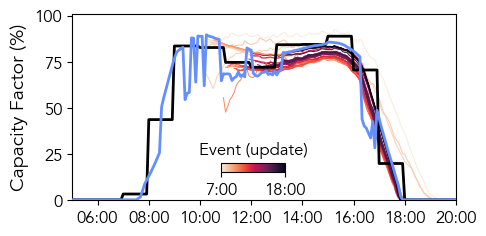

In [69]:
def _plot_dynamic_update(_ax, F_curves_, f_, f_hat_, e_, dx_, dt_,
                         range_ = [60, 240],
                         legend = False,
                         colorbar = True,
                         label = r"$\bar{f} (s)$"):

    f_p_ = np.concatenate([f_, f_hat_], axis = 0)

    _cmap = sns.color_palette("rocket_r", as_cmap=True)
    _norm = plt.Normalize(0., len(F_curves_))

    _ax.plot([], [], 
             lw = 0.75,
             label = label if legend else None, 
             c = "k")
    
    _ax.plot(dt_, 100 * f_p_, 
             c = palette_.loc[0, "ibm"], 
             zorder = 10, 
             label = "CF (actual)" if legend else None, 
             lw = 2, 
             clip_on = True)

    _ax.plot(dt_, 100 * e_, 
             lw = 2, 
             zorder = 9, 
             label = "CF (forecast)" if legend else None, 
             c = "k", 
             clip_on = True)
    
    for i in range(len(F_curves_)):
        focal_curve_ = F_curves_[i]

        _ax.plot(dt_[-focal_curve_.shape[0]:], 100 * focal_curve_, 
                 c = _cmap(_norm(i)), 
                 lw = .75, 
                 zorder = 8)
    
    _ax.set_xticks(dt_[24::24], dx_[24::24], rotation=0)
    _ax.set_ylim(0, 101)
    _ax.set_xlim(dt_[range_[0]], dt_[range_[-1]])
    _ax.set_ylabel("Capacity Factor (%)", size=14)

    _ax.tick_params(axis="both", 
                    labelsize=12)

    if colorbar: 
        cbar = _fig.colorbar(cm.ScalarMappable(_norm, _cmap),
                             cax=_ax.inset_axes([650, 15, 150, 5], transform=_ax.transData),
                             orientation="horizontal")
    
        cbar.set_ticks([0, len(F_curves_)], 
                       labels=["7:00", "18:00"], 
                       size=12)
        
        #cbar.ax.tick_params(length=0)
        
        cbar.ax.set_title("Event (update)", 
                          rotation=0, 
                          size=12)

_fig, _ax = plt.subplots(figsize = (4.75, 2.25), constrained_layout = True)

_plot_dynamic_update(_ax, M_curves_, f_, f_hat_, e_bias_, dx_, dt_,
                     label = 'Focal curves',
                     legend = True,
                     colorbar = True)

# _ax.legend(loc=(0.2, 0.0125),
#            frameon=False, 
#            fontsize=12, 
#            ncol=3)

plt.savefig(path_to_images + f"/dynamic_update-focal_curve-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

(76593,) (211,) (31082, 2) (211, 2)


 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:844: ShapelyDeprecationWarning:__len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:855: ShapelyDeprecationWarning:Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:850: ShapelyDeprecationWarning:__getitem__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
 <__array_function__ internals>:5: ShapelyDeprecationWarning:The array interface is deprecated and will

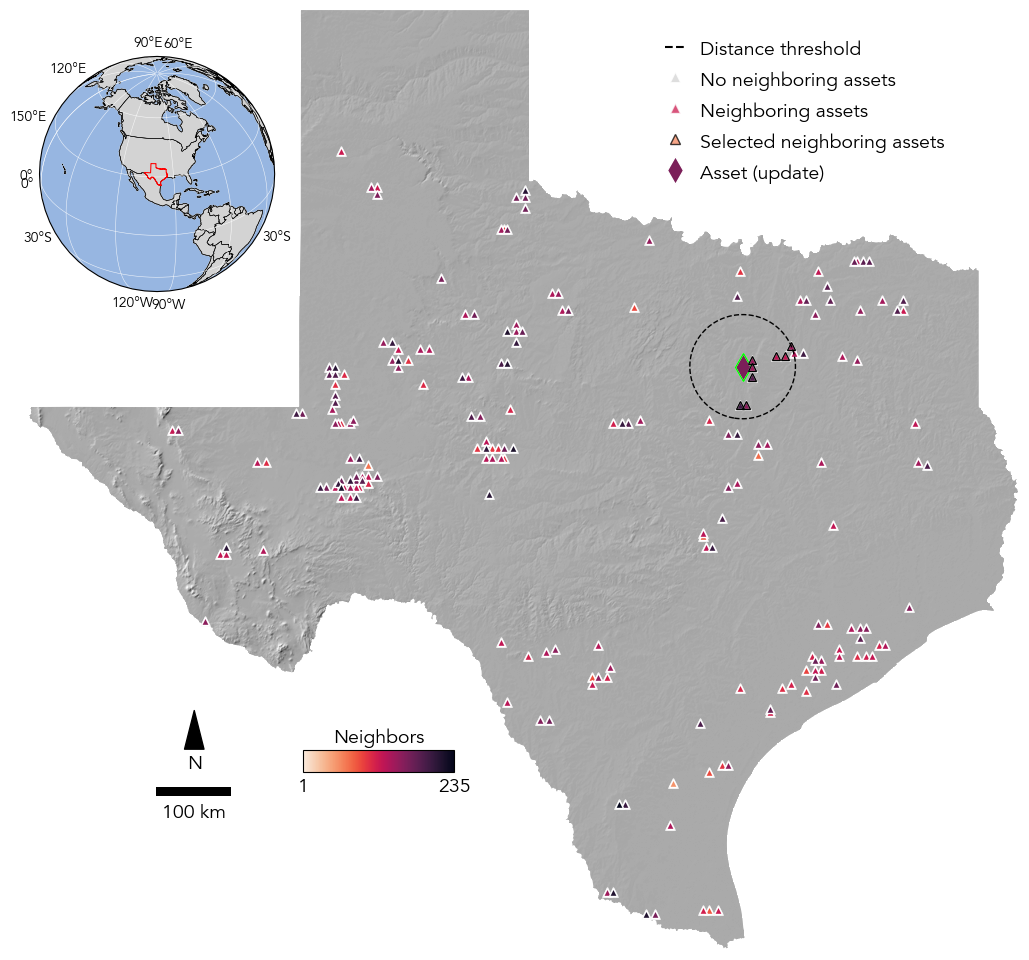

In [68]:
import ee, geemap

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from cartopy.mpl.geoaxes import GeoAxes
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

def _hillshade(_ax, shapefile_):

    # Initialize Earth Engine
    ee.Initialize()
    
    # Get the bounding box from 
    bounds = TX_.total_bounds  # [minx, miny, maxx, maxy]
    roi = geemap.geopandas_to_ee(TX_)  # Convert GeoDataFrame to EE FeatureCollection
    
    _DEM = ee.Image('USGS/SRTMGL1_003').select('elevation')
    #hillshade = ee.Terrain.hillshade(_DEM, 180, 22.5)
    hillshade = ee.Terrain.hillshade(_DEM, 315, 21)
    #hillshade = ee.Terrain.hillshade(_DEM, 315, 20).unitScale(0, 255).pow(1.4).multiply(255) 

    # Download hillshade as a NumPy array
    hillshade_np = geemap.ee_to_numpy(hillshade.clip(roi), 
                                      region=roi, 
                                      scale=1000).astype(float)

    hs = hillshade_np.squeeze()
    hs[hs == 0] = np.nan

    # Create a colormap and set NaNs (bad values) to transparent
    _cmap = cm.get_cmap("Greys_r").copy()
    #_cmap = cm.get_cmap("gray").copy()
    _cmap.set_bad(color=(0, 0, 0, 0))  # RGBA: transparent

    _ax.imshow(hs, 
               cmap=_cmap, 
               extent=[bounds[0], bounds[2], bounds[1], bounds[3]], 
               origin='upper', 
               vmin=1)
    
    return _ax


def _plot_frequency_map(_fig, _ax, shape_, x_tr_, x_ts_, x_, idx_nn_, idx_temp_, idx_spatial_, sigma):

    y_tr_ = x_tr_[idx_nn_, :]
    x_tr_p_, inv_idx_, z_tr_p_ = np.unique(y_tr_, 
                                           return_inverse=True,
                                           return_counts = True, 
                                           axis = 0)

    z_tr_pp_ = z_tr_p_[inv_idx_]
    
    # Step 3: expand back to full x_tr_
    z_tr_ = np.zeros(x_tr_.shape[0], dtype=int)
    z_tr_[idx_nn_] = z_tr_pp_

    print(z_tr_.shape, z_tr_p_.shape, y_tr_.shape, x_tr_p_.shape)
    
    _cmap = sns.color_palette("rocket_r", as_cmap=True)
    _norm = plt.Normalize(1, z_tr_p_.max())

    shape_.plot(ax = _ax, 
                facecolor = 'None', 
                edgecolor = 'w')
    
    # _ax.scatter(x_[0], x_[1],
    #             c="lime",
    #             lw=1,
    #             ec="k",
    #             s=110,
    #             zorder=1,
    #             marker="o",
    #             clip_on=False,
    #             label="Asset (update)")
    
    _ax.plot(x_[0], x_[1],
             c="k",
             marker="None",
             ls="--",
             clip_on=False,
             label="Distance threshold")

    _ax.plot(x_ts_[:, 0], x_ts_[:, 1],
             c="lightgray",
             alpha=0.75,
             ms=7.5,
             marker="^",
             mec="w",
             ls="none",
             mew=.75,
             zorder=2, 
             clip_on=False,
             label="No neighboring assets")
    
    _ax.plot(x_[0], x_[1],
             c=_cmap(_norm(z_tr_p_.max()/2.)),
             alpha=0.75,
             ms=7.5,
             ls="none",
             marker="^",
             mec="w",
             mew=1.0,
             zorder=0, 
             clip_on=False,
             label="Neighboring assets")

    _ax.plot(x_[0], x_[1],
             c=_cmap(_norm(z_tr_p_.max()/4.)),
             alpha=0.75,
             ms=7.5,
             ls="none",
             marker="^",
             mec="k",
             mew=1.0,
             zorder=0, 
             clip_on=False,
             label="Selected neighboring assets")

    for i in np.arange(x_tr_p_.shape[0], dtype=int)[np.argsort(z_tr_p_)]:
        if (x_tr_p_[i, 0] != x_[0]) | (x_tr_p_[i, 1] != x_[1]):
            _ax.plot(x_tr_p_[i, 0], x_tr_p_[i, 1],
                     c=_cmap(_norm(z_tr_p_[i])),
                     ms=6,
                     ls="none",
                     marker="^",
                     mec="w",
                     mew=1.,
                     zorder=6, 
                     clip_on=False)
        else:
            _ax.plot(x_tr_p_[i, 0], x_tr_p_[i, 1],
                     c=_cmap(_norm(z_tr_p_[i])),
                     ms=14,
                     ls="none",
                     marker="d",
                     mec="w",
                     mew=1.,
                     zorder=4, 
                     label = 'Asset (update)',
                     clip_on=False)

    x_tr_p_ = np.unique(x_tr_[idx_spatial_, :], axis=0)
    for i in range(x_tr_p_.shape[0]):
        if (x_tr_p_[i, 0] != x_[0]) | (x_tr_p_[i, 1] != x_[1]):
            _ax.plot(x_tr_p_[i, 0], x_tr_p_[i, 1],
                     ms=6,
                     ls="none",
                     marker="^",
                     c = 'none', 
                     mec="k",
                     mew=1.,
                     zorder=7, 
                     clip_on=False)
        else:
            _ax.plot(x_tr_p_[i, 0], x_tr_p_[i, 1],
                     ms=14,
                     ls="none",
                     marker="d",
                     c = 'none', 
                     mec="lime",
                     mew=1.,
                     zorder=5, 
                     #label = 'Asset (update)',
                     clip_on=False)
    
    minx, miny, maxx, maxy = TX_.total_bounds
    X_, Y_ = np.meshgrid(np.linspace(minx, maxx, 1000), 
                         np.linspace(miny, maxy, 1000))
    
    Z_ = _haversine_dist(x_, np.concatenate([X_.flatten()[:, np.newaxis], 
                                             Y_.flatten()[:, np.newaxis]], axis = 1)).reshape(X_.shape)

    contours = _ax.contour(X_, Y_, Z_, 
                           levels = [sigma], 
                           colors = 'k', 
                           linewidths = 1., 
                           linestyles = 'dashed', 
                           zorder = 11)

    cbar = _fig.colorbar(cm.ScalarMappable(cmap = _cmap),
                         cax=_ax.inset_axes([-103, 27.85, 2.0, 0.25], transform = _ax.transData),
                         orientation="horizontal")

    cbar.set_ticks([0, 1], 
                   labels=[1, int(z_tr_p_.max())], 
                   fontsize=14)
    
    cbar.ax.tick_params(length=0)
    
    cbar.ax.set_title("Neighbors", 
                      rotation = 0, 
                      fontsize = 14)

    _ax.set_axis_off()
    

def _globe_inset(_ax, shape_, x0, y0, width=0.25, height=0.25):
    """
    Add an orthographic globe inset centered on Texas.

    Parameters
    ----------
    _ax : matplotlib Axes / GeoAxes
        Parent axes where the inset will be placed.
    TX_ : GeoDataFrame
        Texas geometry.
    x0, y0 : float
        Lower-left corner of the inset in parent axes coordinates (0–1).
    width, height : float
        Size of the inset, also in parent axes coordinates (0–1).
    """

    # --- Data prep ---
    world_ = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
    world_ = world_.to_crs(epsg=4326)
    shape_ = shape_.to_crs(epsg=4326)

    shape_centroid = shape_.geometry.unary_union.centroid

    ortho = ccrs.Orthographic(central_longitude=shape_centroid.x,
                              central_latitude=shape_centroid.y)

    # Use inset_axes *function*, not _ax.inset_axes
    # bbox_to_anchor=(x0, y0, width, height) is in _ax.transAxes
    _ax_inset = inset_axes(_ax,
                           width="100%",   # 100% of the bbox width
                           height="100%",  # 100% of the bbox height
                           bbox_to_anchor=(x0, y0, width, height),
                           bbox_transform=_ax.transAxes,
                           axes_class=GeoAxes,
                           axes_kwargs=dict(map_projection=ortho),
                           borderpad=0.0)

    # --- Drawing ---
    _ax_inset.add_geometries(world_.geometry,
                             crs=ccrs.PlateCarree(),
                             facecolor="none",
                             edgecolor="k",
                             linewidth=0.25)

    _ax_inset.add_geometries(TX_.geometry,
                             crs=ccrs.PlateCarree(),
                             facecolor="none",
                             edgecolor="r",
                             zorder=10,
                             linewidth=.75)

    gl = _ax_inset.gridlines(crs=ccrs.PlateCarree(),
                             draw_labels=True,      # no labels – small inset
                             linewidth=0.4,
                             color="white",
                             alpha=.825,
                             xlocs=range(-180, 181, 30),
                             ylocs=range(-90, 91, 30))
    
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    _ax_inset.coastlines(linewidth=0.5)
    _ax_inset.add_feature(cfeature.OCEAN, zorder=0)
    _ax_inset.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
    _ax_inset.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=2)
    _ax_inset.set_global()

_fig, _ax = plt.subplots(1, 1, 
                        figsize=(10, 10), 
                        layout="constrained")

# Add inset globe showing Texas
_globe_inset(_ax, TX_, 
             x0=0.005, 
             y0=0.7, 
             width=0.25, 
             height=0.25)

_ax = _hillshade(_ax, TX_)

_plot_frequency_map(_fig, _ax, TX_, x_tr_, x_ts_, x_ts_[asset, :], _meta['idx_neigbors'], 
                    _meta['idx_temporal'], _meta['idx_spatial'], _meta['sigma'])

# Add compass (North arrow)
x, y, arrow_length = 0.1675, 0.2575, 0.06  # relative axes coords

_ax.annotate("N",
             xy=(x, y),
             xytext=(x, y - arrow_length),
             arrowprops=dict(facecolor="k", 
                             arrowstyle="wedge,tail_width=1,shrink_factor=.5"),
             ha="center",
             va="center",
             fontsize=14,
             xycoords=_ax.transAxes)

scalebar = ScaleBar(dx=100,  # scaling factor
                    units="km",
                    dimension="si-length",  # could also be 'imperial-length'
                    location='lower left',
                    length_fraction=0.09,  # fraction of the axis for bar length
                    color="black",
                    box_color="None",
                    box_alpha=1.0,
                    border_pad=9,
                    font_properties={"size": 14})

_ax.add_artist(scalebar)

_ax.legend(frameon=False,
           bbox_to_anchor=(0.625, 0.9875),
           ncol=1,
           fontsize=14)

plt.savefig(path_to_images + f"/hillshade_neighboring_assets-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

-0.23622589531680438 0.22268135904499542
[ 0.22268136 -0.2362259  -0.17975207 -0.05096419  0.13148531  0.11271809
  0.03368916 -0.00918274 -0.12832874  0.10387971]


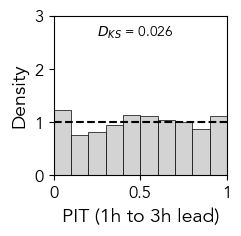

-0.19582185491276438 0.3085399449035813
[ 0.30853994 -0.1431359  -0.19582185 -0.16758494 -0.02462121 -0.04315886
 -0.07650367  0.06209826  0.06077824  0.21941001]


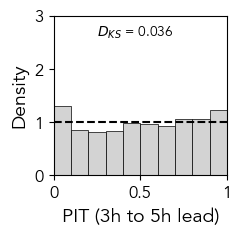

In [9]:
from matplotlib.ticker import FuncFormatter

def clean_fmt(x, pos):
    if abs(x - round(x)) < 1e-9:
        return str(int(round(x)))
    return f"{x:.2g}"

def _plot_PIT(_ax, u_, 
              bins=10,
              v=0.5,
              xlabel = 'PIT'):
    
    vmin= -v
    vmax= v
    KS_stat = _KS(u_)

    u_ = np.sort(u_)
    n = len(u_)

    # --- Histogram ---
    counts_, bins_, patches = _ax.hist(
        u_,
        bins=bins,
        range=(0.0, 1.0),
        density=True,
        lw=0.5,
        edgecolor='k',
        alpha=1
    )

    # deviation from perfect calibration
    deviation = counts_ - 1.
    print(deviation.min(), deviation.max())

    # # --- Compute KS deviation at bin centers ---
    # bin_centers = 0.5 * (bins_[:-1] + bins_[1:])

    # # empirical CDF evaluated at bin centers
    # ecdf_interp = np.searchsorted(u_, bin_centers, side='right') / n

    # deviation = ecdf_interp - bin_centers  # signed deviation
    print(deviation)
    # # --- Colormap centered at 0 ---
    # max_dev = np.max(np.abs(ks_deviation))
    # print(max_dev)
    # normalize deviations for colormap
    # norm = mcolors.Normalize(vmin=vmin, 
    #                          vcenter=0,
    #                          vmax=vmax)
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    cmap = cm.get_cmap("coolwarm")

    for patch, dev in zip(patches, deviation):
        #patch.set_facecolor(cmap(norm(dev)))
        patch.set_facecolor('lightgray')

    # --- Reference line ---
    _ax.axhline(1.0, 
                c = 'k',
                linestyle='--')

    _ax.set_xlim(0, 1)
    _ax.set_ylim(0, 3)

    #_ax.set_xlabel("u = F̂(y_obs)")
    _ax.set_xlabel(xlabel, size=14)
    _ax.set_ylabel("Density", size=14)

    _ax.xaxis.set_major_formatter(FuncFormatter(clean_fmt))

    _ax.tick_params(axis="both", labelsize=12)

    # --- Annotate KS statistic ---
    _ax.text(0.25, 0.95,
             f"$D_{{KS}}$ = {KS_stat:.3f}",
             transform=_ax.transAxes,
             verticalalignment='top')


time = 132
bins = 10

U_ = pd.read_csv(path_to_validation + f"/{resource}_fusion_{time}_ts-4.csv", 
                 low_memory=False).to_numpy()

_fig, _ax = plt.subplots(1, 1, 
                        figsize = (2.3, 2.25), 
                        layout  = "constrained")

lead = 1
_plot_PIT(_ax, U_[:, lead*12:(lead + 2)*12].flatten(), bins,
          xlabel = 'PIT (1h to 3h lead)')

plt.savefig(path_to_images + f"/PIT-{resource}-{lead}-{bins}-{time}.pdf", 
            bbox_inches = "tight")

plt.show()

_fig, _ax = plt.subplots(1, 1, 
                        figsize = (2.3, 2.25), 
                        layout  = "constrained")

lead = 3

_plot_PIT(_ax, U_[:, lead*12:(lead + 2)*12].flatten(), bins, 
          v = 0.4,
          xlabel = 'PIT (3h to 5h lead)')

plt.savefig(path_to_images + f"/PIT-{resource}-{lead}-{bins}-{time}.pdf", 
            bbox_inches = "tight")

plt.show()